# Проект спринта 10: Тортилла. Модель предстаказания массы черепах.



Выполнил: Артем Буров  
https://github.com/TemaQDX/project_turtle

Центр исследования и реабилитации морских черепах «Тортилла» объявил конкурс на разработку модели машинного обучения, которая будет предсказывать массу морских черепах бесконтактным способом.

Партнёры центра «Тортилла» из «Лаборатории перспективных технологий института океанографии» разработали портативную систему компьютерного зрения TurtleCV, которая будет с высокой точностью бесконтактно измерять габариты черепах.

Подсистема компьютерного зрения определяет:
- длину и ширину панциря в миллиметрах (мм);
- габариты головы (мм);
- габариты ласт (мм);
- количество колец на щитках панциря.

Необходимо разработать модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.

## Постановка задачи машинного обучения

- Задача: разработать модель линейной регрессии.
- Целевая переменная: масса черепахи.
- Основная метрика качества модели: MAE.
- Дополнительные метрика качества модели: MSE, R², MAPE.
- Критерии успешности: для целевой популяции зелёных морских черепах массой от 50 до 150 - **MAE не более 5 кг**, **R² не менее 0.97**.

## Описание датасета

Датасет находится в CSV-файле и доступен по ссылке 'https://code.s3.yandex.net/datasets/turtles.csv'.

**Атрибуты:**

`id` — идентификатор измерения.  

`binomial_name` — международное научное название вида черепахи.  

`registration_number` — регистрационный номер черепахи.  

`shell_length` — длина панциря, мм.  

`shell_width` — ширина панциря, мм.  

`head_length` — длина головы, мм.  

`head_width` — ширина головы, мм.  

`flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.  

`flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.  

`circle_count` — количество колец роста на панцире черепахи.  

`measure_count` — количество измерений по модели компьютерного зрения перед усреднением показателей.  

`shell_crack` — наличие трещин панциря.  

`timestamp` — время внесения данных о черепахе.  

`weight` — масса черепахи, кг.  


## Содержимое проекта

1. Загрузка данных и знакомство с ними  


---

## Подключение и настройка библиотек

In [1]:
# Проверка наличия jinja2 для отражения тепловой карты корреляций
try:
    import jinja2
except:
    %pip install jinja2

# Загружаем библиотеки
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)

## 1. Загрузка датасета

- Загрузим данные из файла `turtles.csv` методаом [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html). Установим правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверим, правильно ли прошла загрузка. Данные должны соответствовать описанию.
- С помощью методов библиотеки pandas выведем общие сведения о данных.
- Проведем ознакомление с датасетом. Возможно ли продолжать с ним работу? Если нет — что нужно сделать?

In [2]:
df_turtles = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',')

In [3]:
df_turtles.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [4]:
df_turtles.columns = df_turtles.columns.str.replace(' ', '_')

In [5]:
df_turtles.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration_number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

In [6]:
measure_cols_float = ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'measure_count', 'shell_crack', 'weight']
for col in measure_cols_float:
    df_turtles[col] = pd.to_numeric(df_turtles[col], downcast='float')

measure_cols_int = ['circle_count']
for col in measure_cols_int:
    df_turtles[col] = pd.to_numeric(df_turtles[col], downcast='integer')


df_turtles.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration_number  8832 non-null   str    
 3   shell_length         8774 non-null   float32
 4   shell_width          8861 non-null   float32
 5   head_length          8715 non-null   float32
 6   head_width           8715 non-null   float32
 7   flipper_length_1     8861 non-null   float32
 8   flipper_width_1      8861 non-null   float32
 9   flipper_length_2     8861 non-null   float32
 10  flipper_width_2      8861 non-null   float32
 11  flipper_length_3     8760 non-null   float32
 12  flipper_width_3      8760 non-null   float32
 13  flipper_length_4     8760 non-null   float32
 14  flipper_width_4      8760 non-null   float32
 15  circle_count         8861 non-null   int16  
 16 

## Комментарий по итогам загрузки

1) Загрузка датасета `turtle.csv`  по указанному пути прошла нормально. Данные соответствуют описанию.
2) Датасет содержит **20 атрибутов** и **8 861 строку**.  
3) В наименовани поля `registration number` заменили пропуск ' ' на '_'. Новое название `registration_number`. 
4) Атрибуты с типом данных `int64`: id, shell_width, flipper_length_1, flipper_width_1, flipper_length_2, flipper_width_2, circle_count, timestamp.  
5) Типом данных `str` представлены колонки: binomial_name и registration_number.  
6) К типу `float64` относятся поля: shael_length, head_length, head_width, flipper_length_3, flipper_width_3, flipper_length_4, flipper_width_4, measure_count, shell_crack, weight.  
7) Все числовые атрибуты с замерами длины и ширины были приведены к единому типу `float32`.
8) Тип атрибута с замером числа колец `circle_count` приведен к более оптимальному `int16`.
9) 12 атрибутов из 20 содержат пропуски. Больше всего пропусков в shell_crack.

В датасете необходимо обработать пропуски и проверить на наличие дубликатов.

## 2. Исследовательский анализ данных

### 2.1 Данные о каких черепахах представлены в датасете

In [7]:
# Проверяем уникальные значения в столбце с видам черепах
print(f'Уникальные значения в столбце binomial_name:')
print(df_turtles['binomial_name'].sort_values().unique())
print('Число уникальных значений:', df_turtles['binomial_name'].sort_values().nunique())
print()

Уникальные значения в столбце binomial_name:
<StringArray>
[       'CARETTA CARETTA',         'CHELONIA MYDAS',        'Caretta Caretta',
        'Caretta caretta',         'Chelonia Mydas',         'Chelonia mydas',
   'DERMOCHELYS CORIACEA',   'Dermochelys Coriacea',   'Dermochelys coriacea',
 'ERETMOCHELYS IMBRICATA', 'Eretmochelys Imbricata', 'Eretmochelys imbricata',
  'LEPIDOCHELYS OLIVACEA',    'Lepidochelys Kempii',  'Lepidochelys Olivacea',
    'Lepidochelys kempii',  'Lepidochelys olivacea',        'caretta caretta',
         'chelonia mydas',   'dermochelys coriacea', 'eretmochelys imbricata',
    'lepidochelys kempii',  'lepidochelys olivacea',                      nan]
Length: 24, dtype: str
Число уникальных значений: 23



In [8]:
# Посмотрим на количество записей по видам черепах
df_turtles['binomial_name'].value_counts()

binomial_name
Lepidochelys olivacea     3372
Chelonia mydas            2325
Caretta caretta            674
lepidochelys olivacea      416
Dermochelys coriacea       399
Eretmochelys imbricata     332
Lepidochelys Olivacea      285
chelonia mydas             252
Chelonia Mydas             177
LEPIDOCHELYS OLIVACEA      142
caretta caretta             90
CHELONIA MYDAS              75
Caretta Caretta             46
eretmochelys imbricata      41
dermochelys coriacea        40
CARETTA CARETTA             37
Eretmochelys Imbricata      28
Dermochelys Coriacea        27
Lepidochelys kempii         22
DERMOCHELYS CORIACEA        18
ERETMOCHELYS IMBRICATA       8
lepidochelys kempii          3
Lepidochelys Kempii          3
Name: count, dtype: int64

### Комментарий

В названии видов черепах содержатся дубликаты. Нас интересует вид `Chelonia mydas`, который представлен записями в датасете в категориях: *Chelonia mydas* - 2325 строк, *chelonia mydas* - 252 строки, *Chelonia Mydas* - 177 строк, *CHELONIA MYDAS* - 75 строк.
_______

### 2.2 Проведём отбор записей о виде черепах *Chelonia mydas*

In [9]:
# Прежде всего утсраним дубликаты в названиях черепах
df_turtles['binomial_name'] =  df_turtles['binomial_name'].str.lower()
df_turtles['binomial_name'].unique()

<StringArray>
[       'caretta caretta',  'lepidochelys olivacea',         'chelonia mydas',
 'eretmochelys imbricata',   'dermochelys coriacea',                      nan,
    'lepidochelys kempii']
Length: 7, dtype: str

In [10]:
df_chelodia_mydas = df_turtles[df_turtles['binomial_name'] == 'chelonia mydas'].reset_index(drop=True)
df_chelodia_mydas.info()

<class 'pandas.DataFrame'>
RangeIndex: 2829 entries, 0 to 2828
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   str    
 2   registration_number  2825 non-null   str    
 3   shell_length         2794 non-null   float32
 4   shell_width          2829 non-null   float32
 5   head_length          2790 non-null   float32
 6   head_width           2790 non-null   float32
 7   flipper_length_1     2829 non-null   float32
 8   flipper_width_1      2829 non-null   float32
 9   flipper_length_2     2829 non-null   float32
 10  flipper_width_2      2829 non-null   float32
 11  flipper_length_3     2798 non-null   float32
 12  flipper_width_3      2798 non-null   float32
 13  flipper_length_4     2798 non-null   float32
 14  flipper_width_4      2798 non-null   float32
 15  circle_count         2829 non-null   int16  
 16 

### Комментарий
В датасете устранены неявные дубликаты в названиях черепах `binomial_name`, а затем выделена отдельная выборка только по типу черепах `chelonia mydas`.
__________

### 2.3 Определим все ли признаки необходимо использовать для решения задачи. Удалим признаки, которые никак не помогут.

In [11]:
df_chelodia_mydas.head()

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652.0,118.0,147.0,411.0,386.0,507.0,389.0,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352001
1,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318.0,207.0,248.0,845.0,704.0,661.0,768.0,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074005
2,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926.0,216.0,156.0,562.0,488.0,529.0,432.0,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695000
3,20656,chelonia mydas,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606.0,NaN,NaN,355.0,382.0,411.0,340.0,302.0,355.0,314.0,283.0,62,3.0,1.0,1705325532,51.181999
4,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940.0,187.0,157.0,518.0,557.0,545.0,463.0,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707001


In [12]:
df_chelodia_mydas = df_chelodia_mydas.drop(columns=['binomial_name', 'shell_crack', 'measure_count', 'timestamp'])
df_chelodia_mydas.head()

,id,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
0,25241,0d05dca974d9f624d9c9f8e38817f827,742.0,652.0,118.0,147.0,411.0,386.0,507.0,389.0,414.0,368.0,311.0,325.0,66,56.352001
1,20099,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318.0,207.0,248.0,845.0,704.0,661.0,768.0,587.0,686.0,661.0,585.0,111,154.074005
2,18213,cbb98eb064c1dcefd1a009b21656500f,1010.0,926.0,216.0,156.0,562.0,488.0,529.0,432.0,467.0,434.0,553.0,463.0,76,87.695000
3,20656,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606.0,NaN,NaN,355.0,382.0,411.0,340.0,302.0,355.0,314.0,283.0,62,51.181999
4,20839,8c20d754391001ef4cda77701123f4bc,982.0,940.0,187.0,157.0,518.0,557.0,545.0,463.0,497.0,511.0,541.0,479.0,103,92.707001


### Комментарий

Удалим признаки, которые не принесут никакой пользы при построении модели: `binomial_name` (вид черепах один и тот же, смысла его оставлять нет); `shell_crack` - атрибут содержит большое число пропусков, но также можно с высокой степенью уверенности предположить, что наличие или отсутствие трещин на панцире не влияет на вес животного; `measure_count` - признак, показывающий число измерений одного животного, на основании которого считались средние показатели, а также `timestamp`, показывающий время замера, не повлияют на итоговую линейною модель.
_________

### 2.4 Проверим и обработаем пропуски в данных

In [13]:
def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df_chelodia_mydas)

,Кол-во пропусков,Доля пропусков
registration_number,4,0.0014
shell_length,35,0.0124
head_length,39,0.0138
head_width,39,0.0138
flipper_length_3,31,0.0110
flipper_width_3,31,0.0110
flipper_length_4,31,0.0110
flipper_width_4,31,0.0110
weight,3,0.0011


In [14]:
df_chelodia_mydas = df_chelodia_mydas.dropna(subset=['weight']).reset_index(drop=True)
show_missing_stats(df_chelodia_mydas)

,Кол-во пропусков,Доля пропусков
registration_number,4,0.0014
shell_length,35,0.0124
head_length,39,0.0138
head_width,39,0.0138
flipper_length_3,31,0.0110
flipper_width_3,31,0.0110
flipper_length_4,31,0.0110
flipper_width_4,31,0.0110


### Комментарий

В датасете обнаружены пропуски в атрибутах `registration_number`, `shell_length`, `head_length`, `head_width`, `flipper_length_3`, `flipper_width_3`, `flipper_length_4`, `flipper_width_4`, `measure_count`, `weight`. Число пропусков невелико и составляет немногим более **1%** от общего размера датасета. Самое малое число пропусков обнаружено в поле `weight` - 3 и `registration_number` - 4.

Предполагается неслучайный тип пропусков - `MNAR`. Вероятно связано с проблемами потерь данных при замерах: неработающие датчики, потери при передачи данных в условиях дикой природы и т.п.

**Решение:** на данном этапе удаляем строки с 3 пропусками по массе животных `weight`. Эта цифра, во-первых, незначительна, во-вторых, без массы все остальные признаки для модели не имеют смысла. Нужно оставить все остальные до момента обработки дубликатов и отбора признаков для модели. 
________

### 2.5 Проверим и обработаем дубликаты

In [15]:
# Проверим наличие явных дубликатов
df_chelodia_mydas.duplicated().sum()

np.int64(340)

In [16]:
df_chelodia_mydas.sort_values(by='registration_number')[df_chelodia_mydas.sort_values(by='registration_number').duplicated(keep=False)]

,id,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
2765,24052,0084bcde2ee31ab0b1b3c54ddcbd5d98,868.0,768.0,117.0,128.0,521.0,489.0,512.0,470.0,411.0,335.0,412.0,387.0,80,67.120003
2425,24052,0084bcde2ee31ab0b1b3c54ddcbd5d98,868.0,768.0,117.0,128.0,521.0,489.0,512.0,470.0,411.0,335.0,412.0,387.0,80,67.120003
2480,24549,01ae1863c0868d98c7ec3af168c04ffa,875.0,781.0,186.0,153.0,473.0,520.0,573.0,479.0,370.0,355.0,433.0,351.0,100,69.362999
2820,24549,01ae1863c0868d98c7ec3af168c04ffa,875.0,781.0,186.0,153.0,473.0,520.0,573.0,479.0,370.0,355.0,433.0,351.0,100,69.362999
2389,18249,01f72667b3f84ad1bb4c95591f54ce82,1235.0,1074.0,171.0,230.0,687.0,733.0,741.0,719.0,574.0,523.0,546.0,526.0,80,121.502998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2607,19057,fdee6d250c0fd1e254ec2b04d79757fb,1016.0,957.0,171.0,150.0,588.0,656.0,576.0,594.0,458.0,456.0,489.0,406.0,91,98.737000
2618,17446,ff9d28d28b77729ba3d786f96bf91584,846.0,747.0,123.0,143.0,508.0,496.0,539.0,452.0,392.0,360.0,401.0,299.0,69,63.173000
2278,17446,ff9d28d28b77729ba3d786f96bf91584,846.0,747.0,123.0,143.0,508.0,496.0,539.0,452.0,392.0,360.0,401.0,299.0,69,63.173000
2551,24330,ffea4045eb77613697d0cb118f2d3495,1081.0,981.0,134.0,145.0,658.0,563.0,662.0,508.0,516.0,473.0,493.0,493.0,81,92.349998


In [17]:
df_chelodia_mydas = df_chelodia_mydas.drop_duplicates(keep='first').reset_index(drop=True)

In [18]:
# Проверим наличие явных дубликатов
df_chelodia_mydas.duplicated().sum()

np.int64(0)

In [19]:
df_chelodia_mydas.duplicated(subset='id').sum()

np.int64(0)

In [20]:
df_chelodia_mydas.duplicated(subset='registration_number').sum()

np.int64(3)

In [21]:
df_chelodia_mydas[df_chelodia_mydas.duplicated(subset='registration_number')]

,id,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
435,18763,NaN,1067.0,975.0,153.0,151.0,681.0,561.0,686.0,508.0,489.0,447.0,498.0,393.0,84,102.461998
875,22599,NaN,1471.0,1167.0,259.0,229.0,930.0,703.0,807.0,785.0,663.0,581.0,624.0,653.0,134,166.147995
1159,24708,NaN,877.0,742.0,135.0,149.0,528.0,453.0,509.0,501.0,347.0,413.0,396.0,415.0,49,70.382004


In [22]:
df_chelodia_mydas = df_chelodia_mydas.drop(columns=['id', 'registration_number']).reset_index(drop=True)
df_chelodia_mydas.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
0,742.0,652.0,118.0,147.0,411.0,386.0,507.0,389.0,414.0,368.0,311.0,325.0,66,56.352001
1,1336.0,1318.0,207.0,248.0,845.0,704.0,661.0,768.0,587.0,686.0,661.0,585.0,111,154.074005
2,1010.0,926.0,216.0,156.0,562.0,488.0,529.0,432.0,467.0,434.0,553.0,463.0,76,87.695000
3,703.0,606.0,NaN,NaN,355.0,382.0,411.0,340.0,302.0,355.0,314.0,283.0,62,51.181999
4,982.0,940.0,187.0,157.0,518.0,557.0,545.0,463.0,497.0,511.0,541.0,479.0,103,92.707001


### Комментарий

В датасете было обнаружено 340 явных дубликатов: записей содержащих дублирующие значения по всем атрибутам датасета. Дубликаты были удалены.

Также обнаружено 3 неявных дубликата в поле регистрационного номера черепахи `registration_number`. Причина дубликатов - пропуск в поле NaN - посчитанный как дубликат. Проверка показала, что строки не являются дублирующими, а замеры слишком разные, чтобы их можно было отнести к одному животному. Принято решение оставить эти записи. Само поле `registration_number` вместе с идентификатором замера `id` можно полностью удалить, так как они не влияют на финальную линейную прогнозную модель.
______

### 2.6 Проанализируем и визуализируем распределение признаков. Определим наличие выбросов.

In [23]:
df_chelodia_mydas.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
count,2457.000000,2486.000000,2451.000000,2451.000000,2486.000000,2486.000000,2486.000000,2486.000000,2457.000000,2457.000000,2457.000000,2457.000000,2486.000000,2486.000000
mean,1047.963745,945.018127,169.723373,183.321091,612.010437,549.364441,611.890198,550.252991,487.262909,440.667480,489.176239,440.975159,80.931617,96.068855
std,568.694885,507.521179,41.335453,45.477539,142.589523,131.859100,138.991989,130.856308,110.435272,105.532074,112.562973,104.573837,16.228851,35.149433
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,0.000000
25%,837.000000,752.250000,138.000000,148.000000,502.000000,449.000000,505.000000,449.000000,400.000000,357.000000,400.000000,359.000000,70.000000,67.500751
50%,980.000000,889.000000,163.000000,176.000000,587.000000,527.000000,591.000000,533.000000,473.000000,425.000000,473.000000,423.000000,80.000000,87.900002
75%,1172.000000,1056.000000,195.000000,212.000000,702.000000,632.000000,704.000000,635.000000,558.000000,511.000000,563.000000,509.000000,91.000000,117.629501
95%,1451.000000,1310.750000,249.000000,269.000000,885.750000,797.750000,875.750000,793.750000,690.000000,635.000000,699.000000,637.000000,109.000000,166.310753
99%,1599.880005,1449.350000,279.000000,303.000000,979.300000,903.000000,969.150000,899.150000,773.880005,719.640015,783.440002,718.440002,123.000000,189.654396
max,12840.000000,11550.000000,328.000000,382.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,143.000000,199.960999


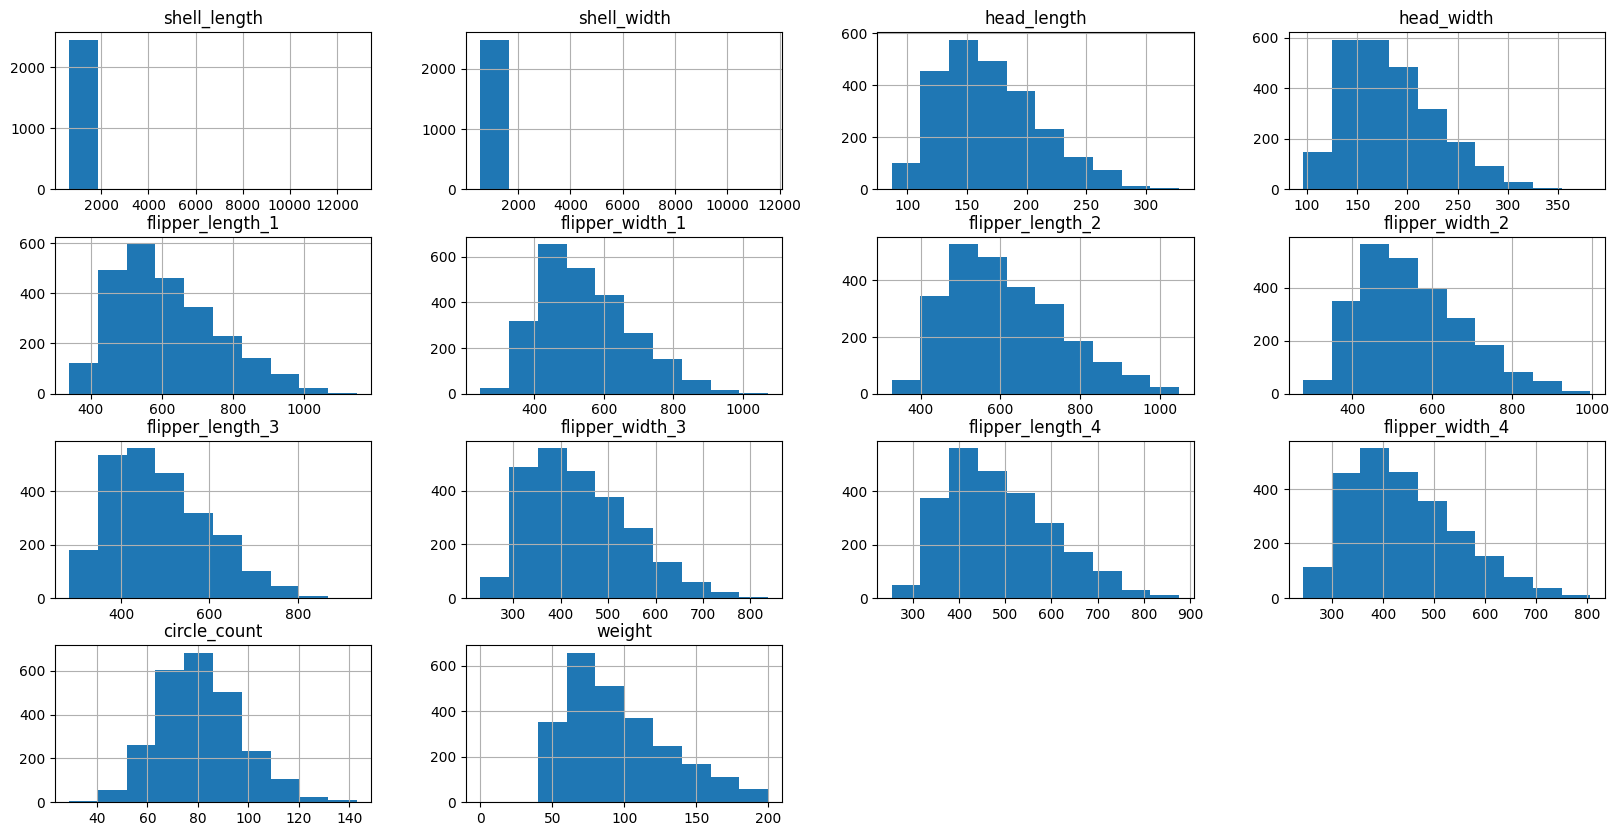

In [24]:
df_chelodia_mydas.hist(figsize=(20, 10));

<Axes: >

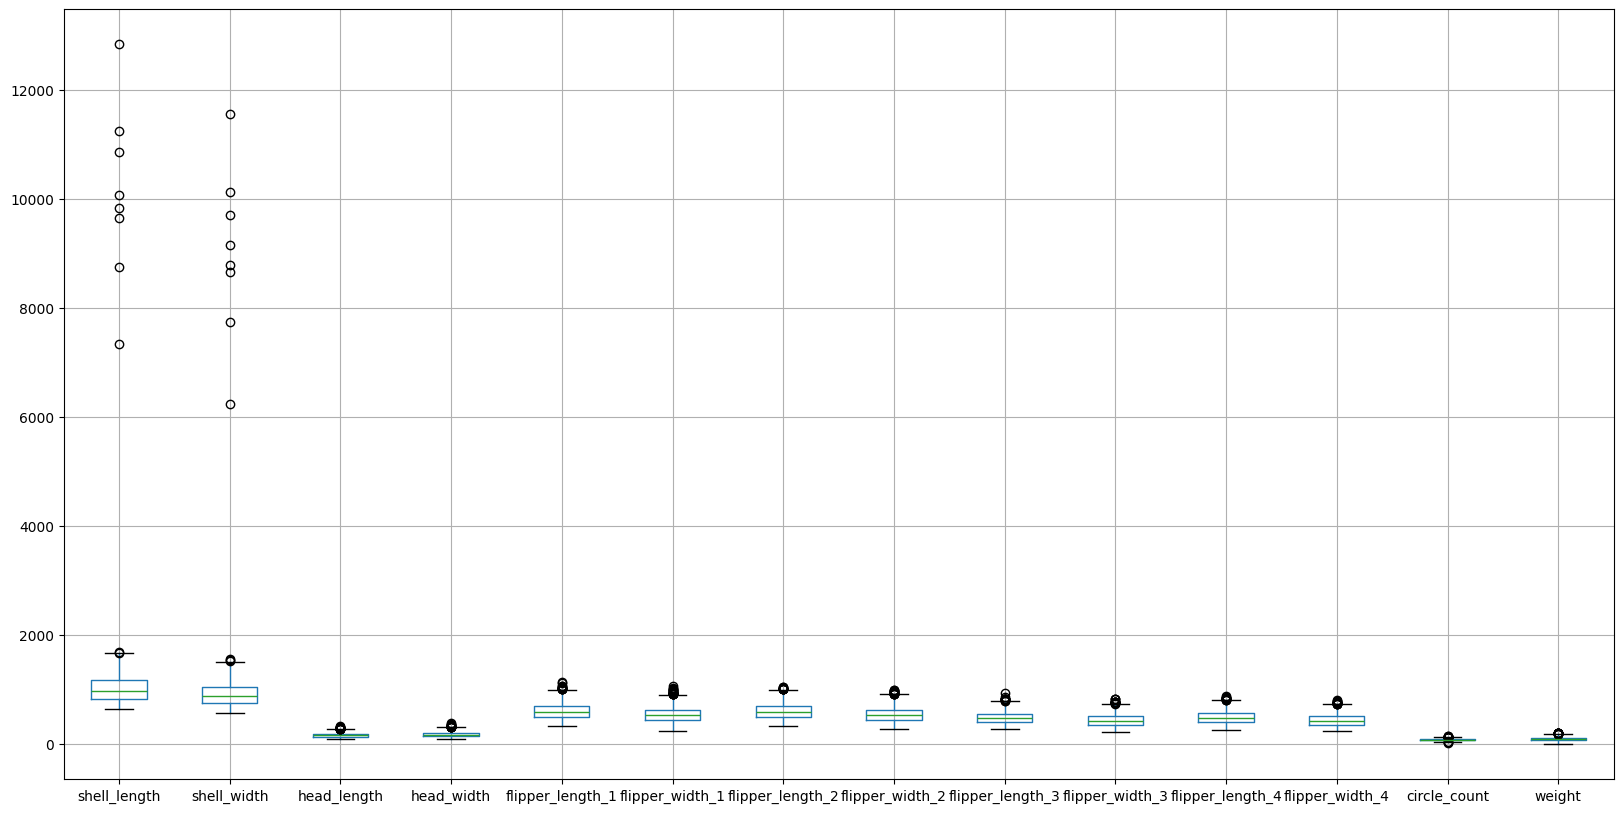

In [25]:
df_chelodia_mydas.boxplot(figsize=(20, 10)) 

In [26]:
df_chelodia_mydas[['shell_length', 'shell_width', 'weight']].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

,shell_length,shell_width,weight
count,2457.000000,2486.000000,2486.000000
mean,1047.963745,945.018127,96.068855
std,568.694885,507.521179,35.149433
min,645.000000,564.000000,0.000000
25%,837.000000,752.250000,67.500751
50%,980.000000,889.000000,87.900002
75%,1172.000000,1056.000000,117.629501
95%,1451.000000,1310.750000,166.310753
99%,1599.880005,1449.350000,189.654396
max,12840.000000,11550.000000,199.960999


In [27]:
df_chelodia_mydas[df_chelodia_mydas['weight'] == 0]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
278,1506.0,1341.0,262.0,265.0,979.0,777.0,910.0,732.0,728.0,651.0,604.0,676.0,109,0.0
1012,780.0,797.0,145.0,150.0,539.0,426.0,536.0,513.0,399.0,388.0,361.0,369.0,70,0.0
1558,892.0,826.0,124.0,158.0,543.0,482.0,517.0,528.0,431.0,442.0,448.0,377.0,83,0.0


In [28]:
df_chelodia_mydas['shell_length'] = df_chelodia_mydas['shell_length'].where(df_chelodia_mydas['shell_length'] <= 2000, df_chelodia_mydas['shell_length'] / 10)
df_chelodia_mydas['shell_width'] = df_chelodia_mydas['shell_width'].where(df_chelodia_mydas['shell_width'] <= 2000, df_chelodia_mydas['shell_width'] / 10)
df_chelodia_mydas = df_chelodia_mydas[df_chelodia_mydas['weight'] > 0].reset_index(drop=True)

In [29]:
df_chelodia_mydas[['shell_length', 'shell_width', 'weight']].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

,shell_length,shell_width,weight
count,2454.000000,2483.000000,2483.000000
mean,1018.386292,918.886841,96.184929
std,222.000305,203.164505,35.011528
min,645.000000,564.000000,49.044998
25%,837.000000,751.500000,67.538002
50%,979.500000,887.000000,87.950996
75%,1167.750000,1054.000000,117.638500
95%,1441.349976,1298.800000,166.322302
99%,1579.939941,1423.540000,189.663876
max,1683.000000,1554.000000,199.960999


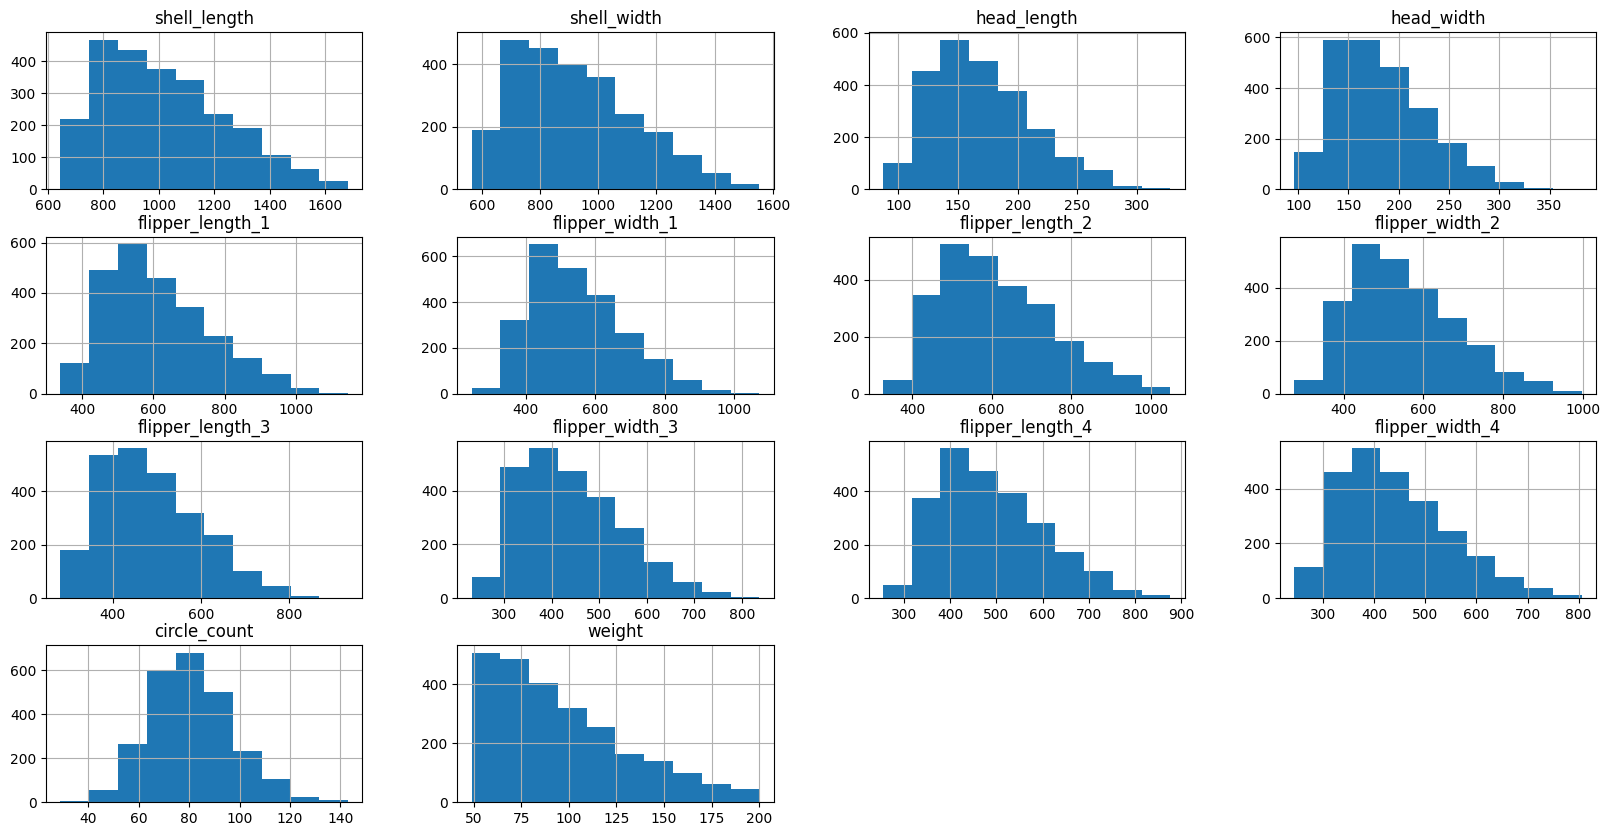

In [30]:
df_chelodia_mydas.hist(figsize=(20, 10));

<Axes: >

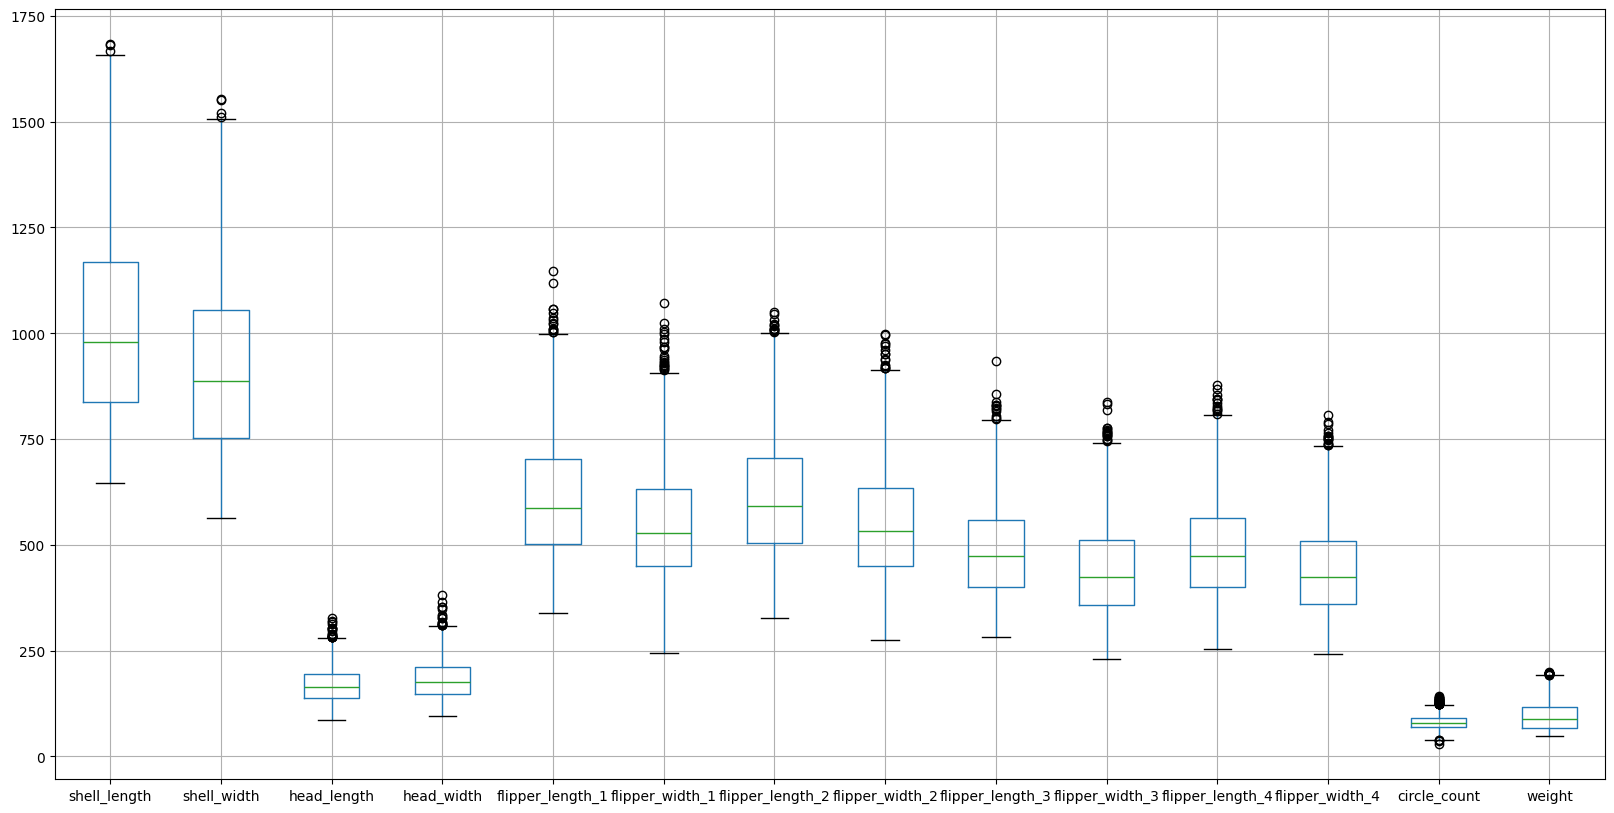

In [31]:
df_chelodia_mydas.boxplot(figsize=(20, 10)) 

### Комментарий

Для анализа распределения признаков были выведены их численные характеристики методов `describe()`, построены гистограммы распределений и визуализация "ящик с усами". Было установлено, что признаки `shell_length` и `shell_width` имеют значительные выбросы, превышающие их 99-й перцентиль. Для длины значение 99-го перцентиля составляет **1599.88 мм**, для ширины **1449.35 мм**. Минимальные значения выбросов превышали **6 метров (6000 мм)**.  
Это совпадает с сообщениям от заказчиков проекта об ошибочном умножении части значений на 10. Действительно длина и ширина черепахи более 6 метров выглядит неправдопообно. В качестве отсечки было выбрано значение **2000 мм**, так как на графике размаха ящик с усами большинство значений было ниже этого порога, а точки выбросов начинались после 6000 мм. Эти значения были поделены на 10, после чего их распределение стало выглядеть намного более гладким и близким к реальности: максимальная длина черепахи не превышает **1599 мм**, а ширина **1448 мм**.  
Другим выбросом стало **нулевое значение веса** по трем наблюдениям. Проверка таких строк показала, что остальные характеристики находятся в их типичном диапазоне: размеры панциря от 800 до 1500 мм, размеры головы от 120 до 279 мм, размеры плавников от 400 до 800 мм, число колец от 70 до 110. Принято решение удалить эти значения, так как восстановить их не представляется возможным, а для общего размера выборки число удаленных записей очень мало.
_________


### 2.7 Масштаб признаков

In [32]:
df_chelodia_mydas.describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
count,2454.000000,2483.000000,2448.000000,2448.000000,2483.000000,2483.000000,2483.000000,2483.000000,2454.000000,2454.000000,2454.000000,2454.000000,2483.000000,2483.000000
mean,1018.386292,918.886841,169.714462,183.311676,611.919861,549.349548,611.838928,550.203796,487.223724,440.602692,489.198456,440.934814,80.923882,96.184929
std,222.000305,203.164505,41.305332,45.467571,142.471085,131.829437,138.925766,130.881638,110.375587,105.505768,112.575104,104.512016,16.227341,35.011528
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,49.044998
25%,837.000000,751.500000,138.000000,148.000000,501.500000,449.000000,504.500000,449.000000,400.000000,357.000000,400.000000,359.000000,70.000000,67.538002
50%,979.500000,887.000000,163.000000,176.000000,587.000000,527.000000,591.000000,533.000000,473.000000,425.000000,473.000000,423.000000,80.000000,87.950996
75%,1167.750000,1054.000000,195.000000,212.000000,702.000000,632.000000,704.000000,635.000000,558.000000,511.000000,563.000000,508.750000,91.000000,117.638500
95%,1441.349976,1298.800000,248.649994,269.000000,884.500000,797.900000,874.800000,793.900000,689.349976,635.000000,699.000000,637.000000,109.000000,166.322302
99%,1579.939941,1423.540000,279.000000,303.000000,979.360000,903.000000,969.180000,899.180000,773.940002,719.820007,783.469971,718.469971,123.000000,189.663876
max,1683.000000,1554.000000,328.000000,382.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,143.000000,199.960999


### Комментарий

Помасштабу признаки делятся на 4 группы:
1. Размеры панциря (диапазон от **600 до 1700**)
2. Размеры головы (диапазон от **80 до 400**)
3. Размеры плавников (диапазон от **200 до 1200**)
4. Число колец (диапазон от **30 до 150**).

Признаки необходимо привести к единому масштабу, используя методы стандартизации и мин-макс. Приведение к единому масштабу следует сделать после отбора только нужных для прогнозной модели признаков, на основании анализа корреляции и устранения мультиколлинеарности. Также необходимо предварительно разбить датасет на обучающую, валидационую и тестовую выборки с целью недопущения утечки данных.
_____________

### 2.8 Анализ корреляцию между признаками и целевой переменной. Выбор признаков для дальнейшего построения прогнозной модели.

In [33]:
df_chelodia_mydas.corr(method='pearson')['weight'][:-1].to_frame().style.background_gradient(cmap='coolwarm')

,weight
shell_length,0.984461
shell_width,0.968626
head_length,0.875362
head_width,0.868456
flipper_length_1,0.927451
flipper_width_1,0.897135
flipper_length_2,0.923784
flipper_width_2,0.903030
flipper_length_3,0.922198
flipper_width_3,0.901860


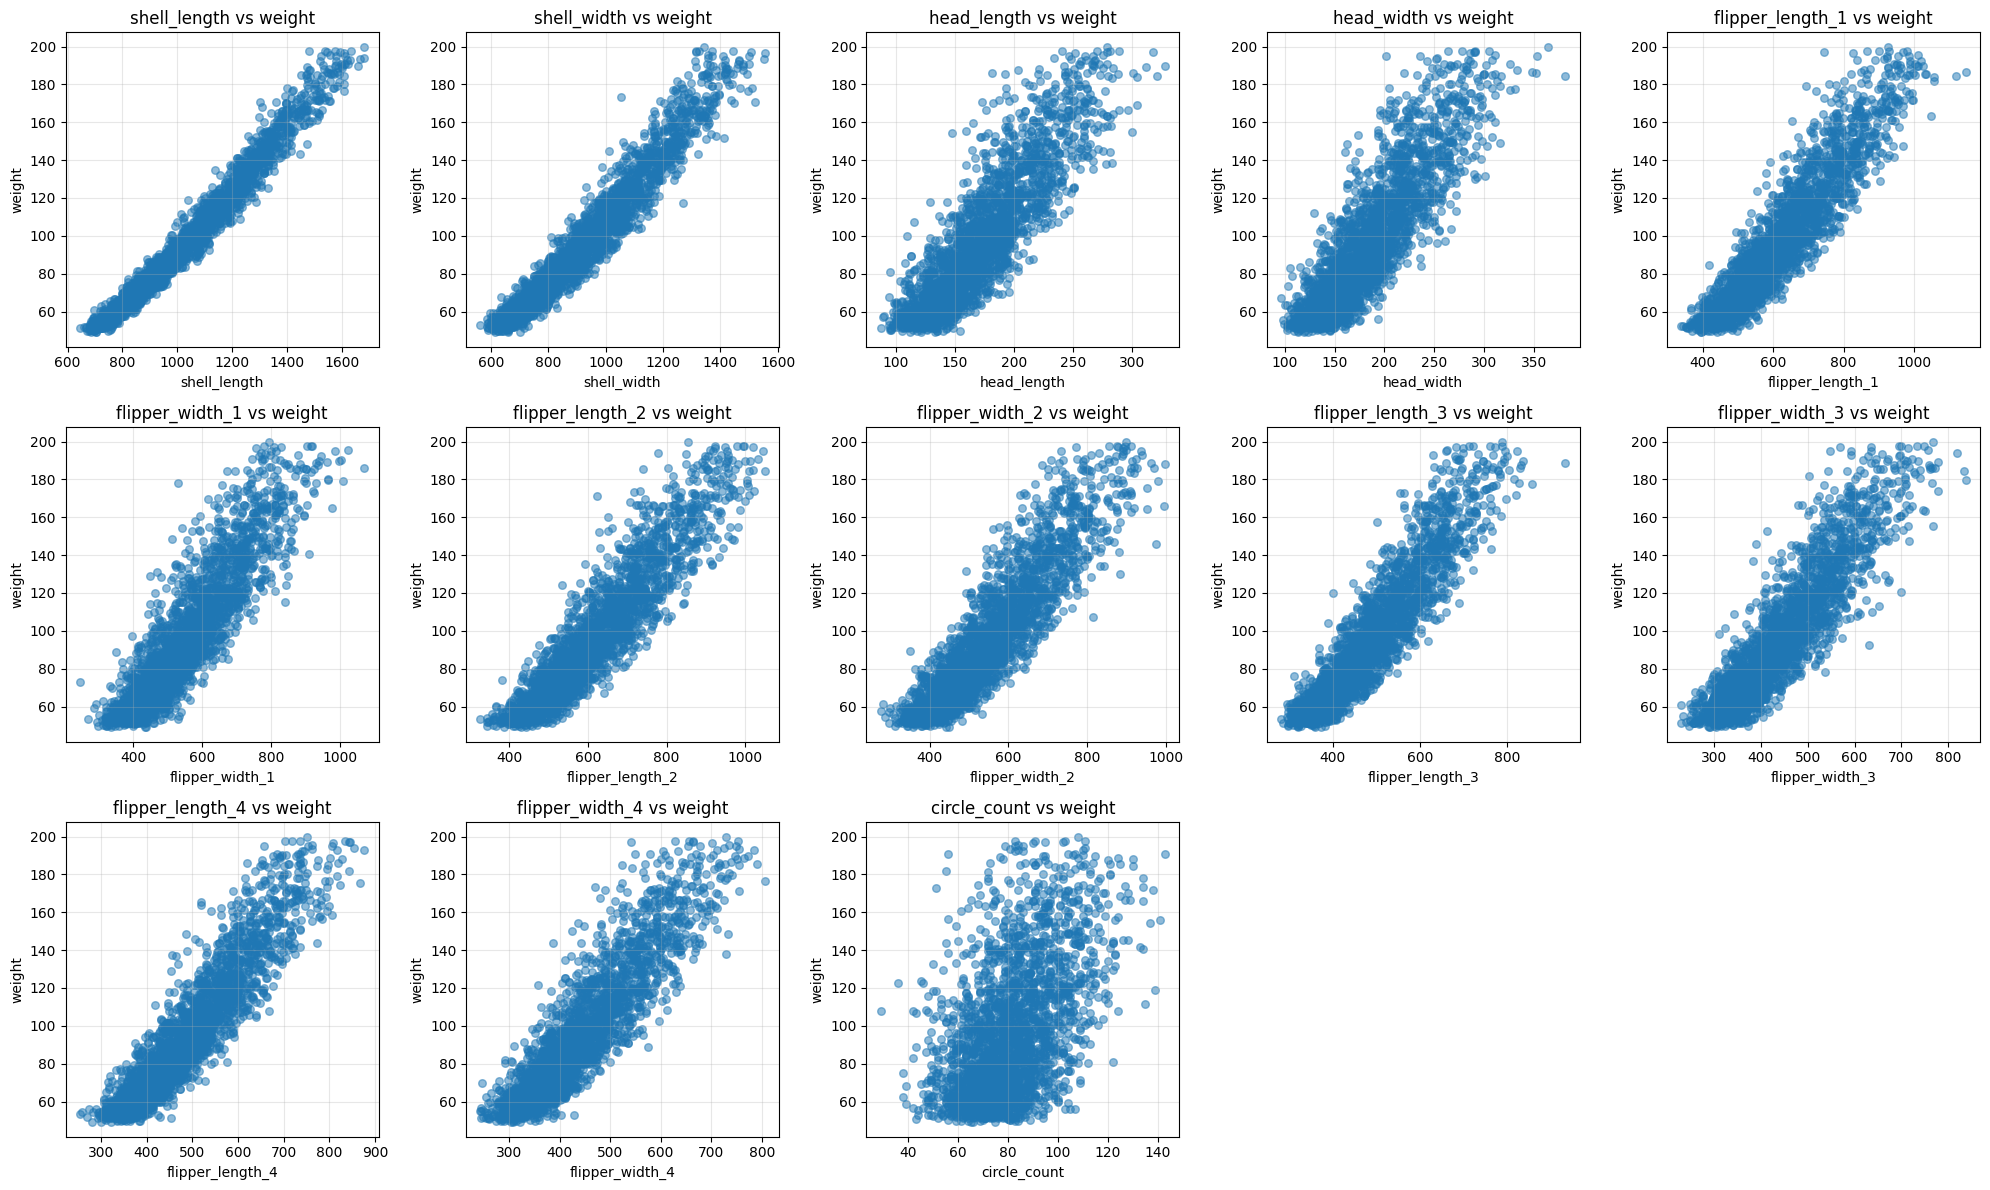

In [34]:
target_variable = df_chelodia_mydas.columns[-1]
feature_columns = df_chelodia_mydas.columns[:-1]

# Определяем размер сетки (3x5)
n_rows = 3
n_cols = 5

# Создаем основную фигуру с субплотами
fig = plt.figure(figsize=(20, 12))

# Проходим по всем признакам
for idx, feature in enumerate(feature_columns):
    if idx >= n_rows * n_cols:  # Ограничиваем количество графиков
        break
    
    # Создаем субплот
    ax = fig.add_subplot(n_rows, n_cols, idx + 1)
    
    # Основной scatter plot
    ax.scatter(df_chelodia_mydas[feature], df_chelodia_mydas[target_variable], alpha=0.5, s=30)
    
    # Настройки внешнего вида
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel(target_variable, fontsize=10)
    ax.set_title(f'{feature} vs {target_variable}', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Добавляем гистограммы по краям (упрощенный вариант jointplot)
    # Для полноценных маргинальных гистограмм потребуется создание дополнительных осей

# Настройка отступов между графиками
plt.tight_layout()
plt.show()

### Комментарий

Матрица, построенная по коэффициенту корреляции Пирсона (Pearson), показывает **сильную корреляцию** почти между всеми признаками и целевой переменной `weight`. Для первой группы признаков (`shell_length` и `shell_width`) самый высокий коэффициент в выборке **0.97-0.98**, для второй группы признаков `head_length` и `head_width` - **0.87**, для третьей группы с замерами длины и ширины плавников (`flipper_length` и `flipper_width`) - **0.9-0.93**. Умеренная корреляция наблюдается только с признаком `circle_count` (число колец) - **0.51**.  
Точечные диаграммы **визуально подтверждают эти выводы**, сделанные на основании корреляционной матрицы. Самую высокую плотность линейной корреляции видно на графиках первой группы признаков с размерами панциря. Далее по возрастанию степени рассеяния идёт группа признаков с замерами плавников, затем головы черепахи, и в заключении замеры числа колец.
____________

### 2.9 Проверка мультиколлинеарности признаков. Способы ее устранения.

In [35]:
df_chelodia_mydas.corr(method='pearson').iloc[:-1,:-1].style.background_gradient(cmap='coolwarm')

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
shell_length,1.000000,0.959955,0.867124,0.860427,0.920007,0.890818,0.917217,0.897907,0.915463,0.895125,0.919118,0.895308,0.500605
shell_width,0.959955,1.000000,0.851398,0.843446,0.904139,0.876169,0.905369,0.884712,0.901721,0.880621,0.902835,0.884019,0.495655
head_length,0.867124,0.851398,1.000000,0.763530,0.813087,0.788752,0.815008,0.796350,0.810695,0.792826,0.810176,0.803061,0.452650
head_width,0.860427,0.843446,0.763530,1.000000,0.808789,0.780595,0.806570,0.791034,0.801909,0.786405,0.816958,0.795211,0.445499
flipper_length_1,0.920007,0.904139,0.813087,0.808789,1.000000,0.836467,0.869192,0.850201,0.856647,0.841457,0.864910,0.838900,0.474170
flipper_width_1,0.890818,0.876169,0.788752,0.780595,0.836467,1.000000,0.833617,0.818607,0.834872,0.817634,0.835482,0.814079,0.477996
flipper_length_2,0.917217,0.905369,0.815008,0.806570,0.869192,0.833617,1.000000,0.842213,0.858202,0.841392,0.856975,0.841569,0.470078
flipper_width_2,0.897907,0.884712,0.796350,0.791034,0.850201,0.818607,0.842213,1.000000,0.841124,0.824919,0.847327,0.818643,0.462638
flipper_length_3,0.915463,0.901721,0.810695,0.801909,0.856647,0.834872,0.858202,0.841124,1.000000,0.842082,0.865100,0.841038,0.465957
flipper_width_3,0.895125,0.880621,0.792826,0.786405,0.841457,0.817634,0.841392,0.824919,0.842082,1.000000,0.846154,0.822725,0.457159


### Комментарий

Признаки матрицы "объект-признак" имеют высокую корреляцию между собой **(0.89 - 0.96)**, за исключением признака `cirle_count` (число колец) со слабо-умеренным показателем корреляции со всеми остальными признаками от **0.46 до 0.50**. Это говорит о мультиколлинеарности признаков.  
В дальнейшем задействуем два подхода для возможного решения:
1) Отбор признаков, исходя из логики процесса измерения показателей черепах в естественной среде обитания. Например, проще измерить один только панцирь, без замеров плавников. При высокой корреляции длины и ширины этих признаков, быстрее и дешевле измерить что-то одно и получить расчет с той же степенью точности, что и при замерах всех показателей.
2) L1-регуляризацию (Lasso) для исключения наиенее значимых признаков.
3) Feature-engineering. Вероятно можно объединить группы признаков (`shell`, `head`, `flipper`) и посчитать общую L2 норму длины и ширины. Для четырёх плавников можно посчитать усредненную L2 норму. Таким образом мы получим 4 уникальных по смыслу признака вместо 13, которые дублируют друг друга. 
___________

## Итоги исследовательского анализа данных

В ходе исследовательского анализа датасета с измерениями габаритов морских черепах вида *Chelonia mydas* была проведена комплексная обработка данных и их подготовка к построению прогнозной модели для предсказания массы животного (`weight`).

Сначала были устранены неявные дубликаты в поле `binomial_name`, где встречались разные варианты написания названия вида, а затем удалены 340 явных дубликатов записей. Записи с неявными дубликатами в `registration_number` оставлены, поскольку проверка показала, что они относятся к разным замерам.

Далее выполнен отбор признаков: исключены `binomial_name` (вид в выборке один), `shell_crack` (много пропусков и маловероятное влияние на вес), `measure_count` и `timestamp` (не влияют на итоговую модель), а также `registration_number` и `id` (идентификаторы не нужны для прогноза).

Анализ пропусков показал, что их доля составляет немногим более 1 % от общего размера датасета. Пропуски обнаружены в нескольких полях, включая `weight` (3 строки) и `registration_number` (4 строки). Поскольку масса — ключевая переменная, записи с пропусками в `weight` были удалены. Предполагаемый тип пропусков — MNAR (неслучайный), что может быть связано с проблемами сбора данных в дикой природе.

Особое внимание уделено обработке выбросов. Выявлены аномальные значения длины и ширины панциря свыше 6 000 мм — вероятно, из‑за ошибки умножения на 10. В качестве отсечки выбрано значение 2 000 мм: все превышающие его значения поделены на 10, что привело распределение в реалистичный диапазон (максимальная длина — 1 599 мм, ширина — 1 448 мм). Также удалены три записи с нулевым весом при нормальных размерах черепахи — восстановить эти значения невозможно, а их доля в выборке незначительна.

При анализе масштаба признаков выявлено четыре группы с разными диапазонами значений: размеры панциря (600–1 700 мм), головы (80–400 мм), плавников (200–1 200 мм) и число колец (30–150). Перед обучением модели потребуется масштабирование (стандартизация или мин‑макс), которое следует выполнять после отбора признаков и разделения датасета на обучающую, валидационную и тестовую выборки во избежание утечки данных.

Корреляционный анализ с использованием коэффициента Пирсона показал высокую связь большинства признаков с целевой переменной `weight`. Наибольшая корреляция наблюдается у размеров панциря (`shell_length`, `shell_width` — $0{,}97–0{,}98$), далее следуют размеры плавников (`flipper_length_n`, `flipper_width_n` — $0{,}90–0{,}93$) и головы (`head_length`, `head_width` — $0{,}87$). Умеренная корреляция зафиксирована для числа колец (`circle_count` — $0{,}51$).

Выявлена высокая мультиколлинеарность между большинством признаков ($0{,}89–0{,}96$), за исключением `circle_count`, корреляция которого с остальными находится в диапазоне $0{,}46–0{,}50$. Для устранения этой проблемы предложены следующие подходы: отбор признаков по практической целесообразности измерений (например, использование только размеров панциря вместо всех габаритов), применение L1‑регуляризации (Lasso) для исключения наименее значимых переменных и feature engineering — объединение групп признаков через L2‑норму или усреднение, что позволит сократить число переменных с 13 до 4 уникальных признаков.
___________

## 3. Предобработка данных

### 3.1 Разделение выборки на обучающую (60%), валидационную (20%) и тестовую (20%)

In [36]:
random_state = 52
X = df_chelodia_mydas[feature_columns]
y = df_chelodia_mydas[target_variable].to_frame()

In [37]:
# Разделим на train_val и test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y,
                                                    test_size=0.2,
													shuffle=True,
                                                    random_state=random_state)# напишите ваш код здесь

# Выделите на train и val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,
                                                    test_size=0.25,
													shuffle=True,
                                                    random_state=random_state) # напишите ваш код здесь

total_rows = X.shape[0]
print(f'Размер выборки X_train_val: {X_train_val.shape[0] / total_rows * 100:.0f}%')
print(f'Размер выборки y_train_val: {y_train_val.shape[0] / total_rows * 100:.0f}%')
print(f'Размер выборки X_test: {X_test.shape[0] / total_rows * 100:.0f}%')
print(f'Размер выборки y_test: {y_test.shape[0] / total_rows * 100:.0f}%')
print(f'Размер выборки X_train: {X_train.shape[0] / total_rows * 100:.0f}%')
print(f'Размер выборки y_train: {y_train.shape[0] / total_rows * 100:.0f}%')
print(f'Размер выборки X_val: {X_val.shape[0] / total_rows * 100:.0f}%')
print(f'Размер выборки y_val: {y_val.shape[0] / total_rows * 100:.0f}%')

Размер выборки X_train_val: 80%
Размер выборки y_train_val: 80%
Размер выборки X_test: 20%
Размер выборки y_test: 20%
Размер выборки X_train: 60%
Размер выборки y_train: 60%
Размер выборки X_val: 20%
Размер выборки y_val: 20%


### Комментарий

Датасет `df_chelodia_mydas` разделен на матрицу "объект-признак" `X` с атрибутами изменений длины и ширины панциря, головы, плавников и числа колец на панцире и на целевую переменную `y`, содержащую замеры веса морских черепах.  
Обе выборки разделены на обучающую (60%), валидационную (20%) и тестовую (20%).
__________

### 3.2 Обработка пропусков

In [38]:
show_missing_stats(df_chelodia_mydas)

,Кол-во пропусков,Доля пропусков
shell_length,29,0.0117
head_length,35,0.0141
head_width,35,0.0141
flipper_length_3,29,0.0117
flipper_width_3,29,0.0117
flipper_length_4,29,0.0117
flipper_width_4,29,0.0117


In [39]:
show_missing_stats(X_train)

,Кол-во пропусков,Доля пропусков
shell_length,19,0.0128
head_length,22,0.0148
head_width,22,0.0148
flipper_length_3,15,0.0101
flipper_width_3,15,0.0101
flipper_length_4,15,0.0101
flipper_width_4,15,0.0101


In [40]:
show_missing_stats(y)

'Пропусков в данных нет'

In [41]:
X_train[X_train['shell_length'].isna()]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
1068,NaN,704.0,145.0,161.0,460.0,438.0,531.0,439.0,381.0,379.0,447.0,380.0,48
1591,NaN,770.0,144.0,148.0,462.0,418.0,487.0,495.0,507.0,364.0,392.0,363.0,71
1993,NaN,1090.0,195.0,145.0,631.0,633.0,698.0,627.0,483.0,525.0,568.0,479.0,76
166,NaN,696.0,127.0,145.0,478.0,474.0,487.0,521.0,373.0,325.0,380.0,336.0,83
1923,NaN,861.0,181.0,173.0,621.0,557.0,604.0,544.0,485.0,526.0,486.0,438.0,87
1350,NaN,1186.0,178.0,265.0,802.0,631.0,778.0,623.0,561.0,664.0,652.0,525.0,83
1167,NaN,1015.0,198.0,223.0,645.0,601.0,711.0,563.0,495.0,503.0,528.0,571.0,83
2238,NaN,683.0,112.0,138.0,503.0,404.0,379.0,384.0,370.0,327.0,357.0,364.0,71
2444,NaN,731.0,138.0,142.0,499.0,441.0,535.0,495.0,438.0,350.0,421.0,455.0,88
1637,NaN,935.0,168.0,182.0,635.0,657.0,475.0,480.0,535.0,431.0,466.0,422.0,95


In [42]:
X_train[X_train['head_length'].isna()]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
1063,1047.0,876.0,NaN,NaN,589.0,516.0,634.0,506.0,489.0,574.0,539.0,383.0,101
2179,850.0,753.0,NaN,NaN,519.0,465.0,557.0,543.0,404.0,438.0,402.0,378.0,70
2079,980.0,867.0,NaN,NaN,574.0,413.0,527.0,577.0,529.0,416.0,523.0,514.0,85
1558,736.0,722.0,NaN,NaN,451.0,411.0,439.0,382.0,391.0,354.0,386.0,343.0,58
1440,719.0,616.0,NaN,NaN,438.0,416.0,405.0,357.0,339.0,272.0,325.0,245.0,85
882,1196.0,1121.0,NaN,NaN,793.0,650.0,769.0,644.0,539.0,570.0,550.0,461.0,45
1362,1120.0,938.0,NaN,NaN,641.0,616.0,572.0,513.0,603.0,488.0,517.0,469.0,68
1636,877.0,784.0,NaN,NaN,539.0,480.0,544.0,494.0,418.0,384.0,354.0,322.0,88
2353,714.0,664.0,NaN,NaN,393.0,355.0,396.0,426.0,386.0,312.0,270.0,313.0,66
2122,1253.0,1211.0,NaN,NaN,818.0,698.0,764.0,728.0,629.0,580.0,653.0,644.0,87


In [43]:
X_train[X_train['flipper_length_3'].isna()]

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
1859,1136.0,1040.0,169.0,202.0,711.0,672.0,653.0,595.0,NaN,NaN,NaN,NaN,102
257,883.0,753.0,183.0,154.0,504.0,473.0,537.0,429.0,NaN,NaN,NaN,NaN,82
126,1316.0,1177.0,215.0,231.0,710.0,743.0,742.0,732.0,NaN,NaN,NaN,NaN,74
884,831.0,718.0,132.0,168.0,472.0,436.0,488.0,425.0,NaN,NaN,NaN,NaN,80
422,814.0,684.0,148.0,175.0,542.0,492.0,445.0,498.0,NaN,NaN,NaN,NaN,76
392,864.0,717.0,125.0,152.0,411.0,387.0,552.0,506.0,NaN,NaN,NaN,NaN,81
220,1173.0,1058.0,159.0,194.0,729.0,694.0,613.0,648.0,NaN,NaN,NaN,NaN,88
1909,919.0,820.0,163.0,154.0,575.0,366.0,570.0,464.0,NaN,NaN,NaN,NaN,70
992,1082.0,856.0,159.0,181.0,603.0,578.0,588.0,556.0,NaN,NaN,NaN,NaN,94
1356,796.0,724.0,123.0,128.0,447.0,442.0,443.0,462.0,NaN,NaN,NaN,NaN,78


In [44]:
X_train.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
count,1470.000000,1489.000000,1467.000000,1467.000000,1489.000000,1489.000000,1489.000000,1489.000000,1474.000000,1474.000000,1474.000000,1474.000000,1489.000000
mean,1012.807495,913.777039,169.043625,181.862305,607.418396,546.182007,609.083923,546.916748,485.176392,439.242889,487.109222,438.884674,81.111484
std,220.690063,202.749985,41.568096,45.591969,141.727493,129.895447,137.751175,130.017349,109.639610,105.178589,111.203140,105.115746,16.172572
min,645.000000,587.000000,87.000000,96.000000,343.000000,245.000000,327.000000,276.000000,282.000000,235.000000,254.000000,243.000000,29.000000
25%,834.000000,750.000000,137.000000,147.000000,498.000000,448.000000,499.000000,447.000000,400.000000,356.250000,398.250000,357.000000,70.000000
50%,970.500000,881.000000,162.000000,175.000000,582.000000,523.000000,591.000000,529.000000,467.000000,423.000000,473.000000,421.000000,80.000000
75%,1156.000000,1051.000000,194.000000,210.000000,698.000000,627.000000,693.000000,633.000000,555.750000,507.000000,560.000000,504.750000,91.000000
max,1683.000000,1521.000000,328.000000,382.000000,1147.000000,1003.000000,1049.000000,997.000000,857.000000,837.000000,855.000000,806.000000,143.000000


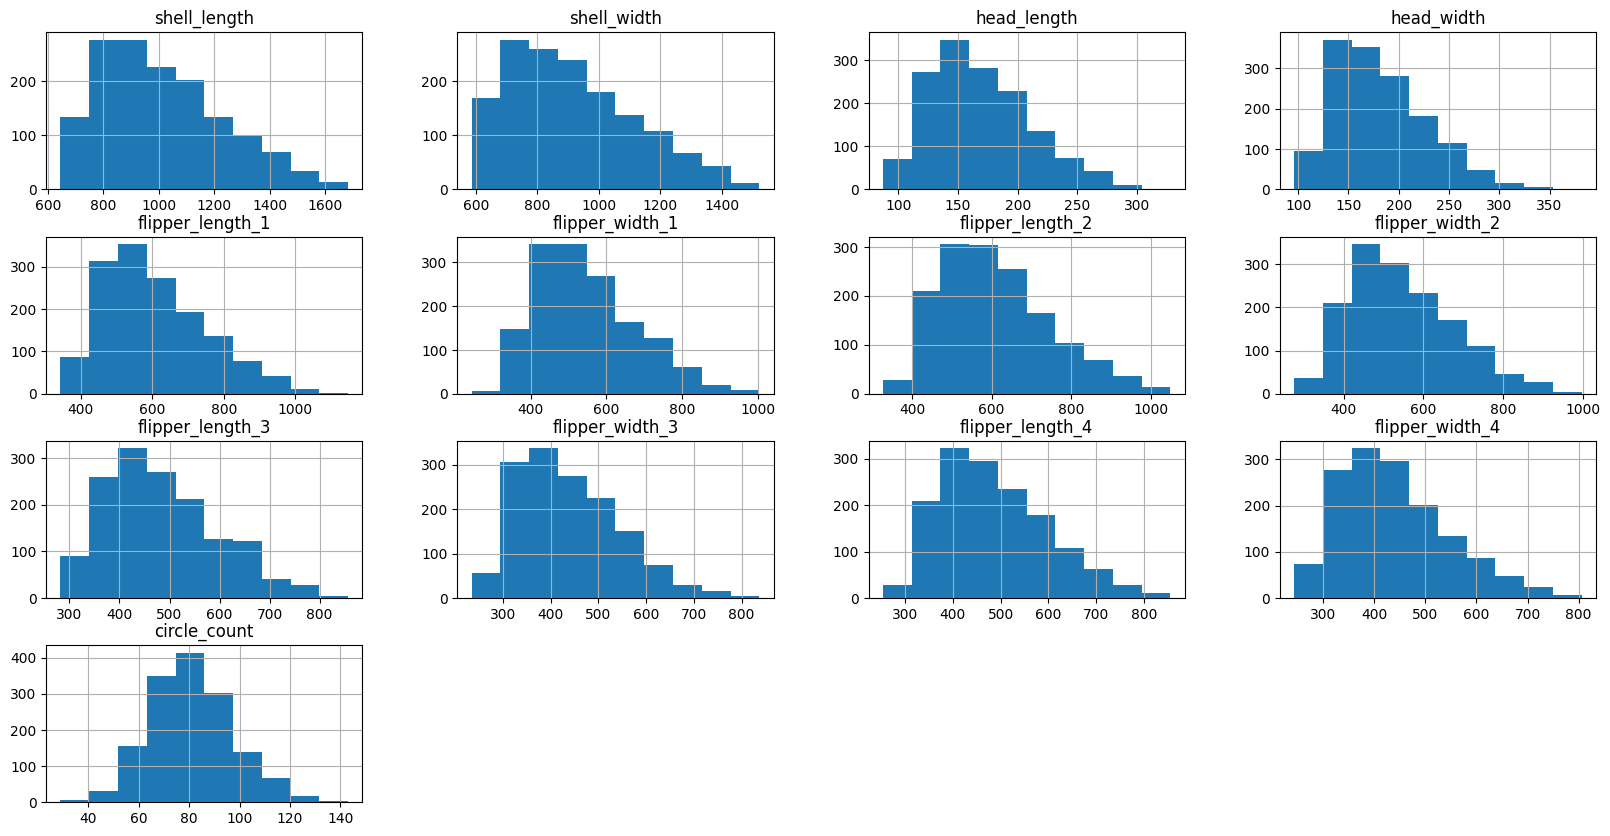

In [45]:
X_train.hist(figsize=(20, 10));

<Axes: >

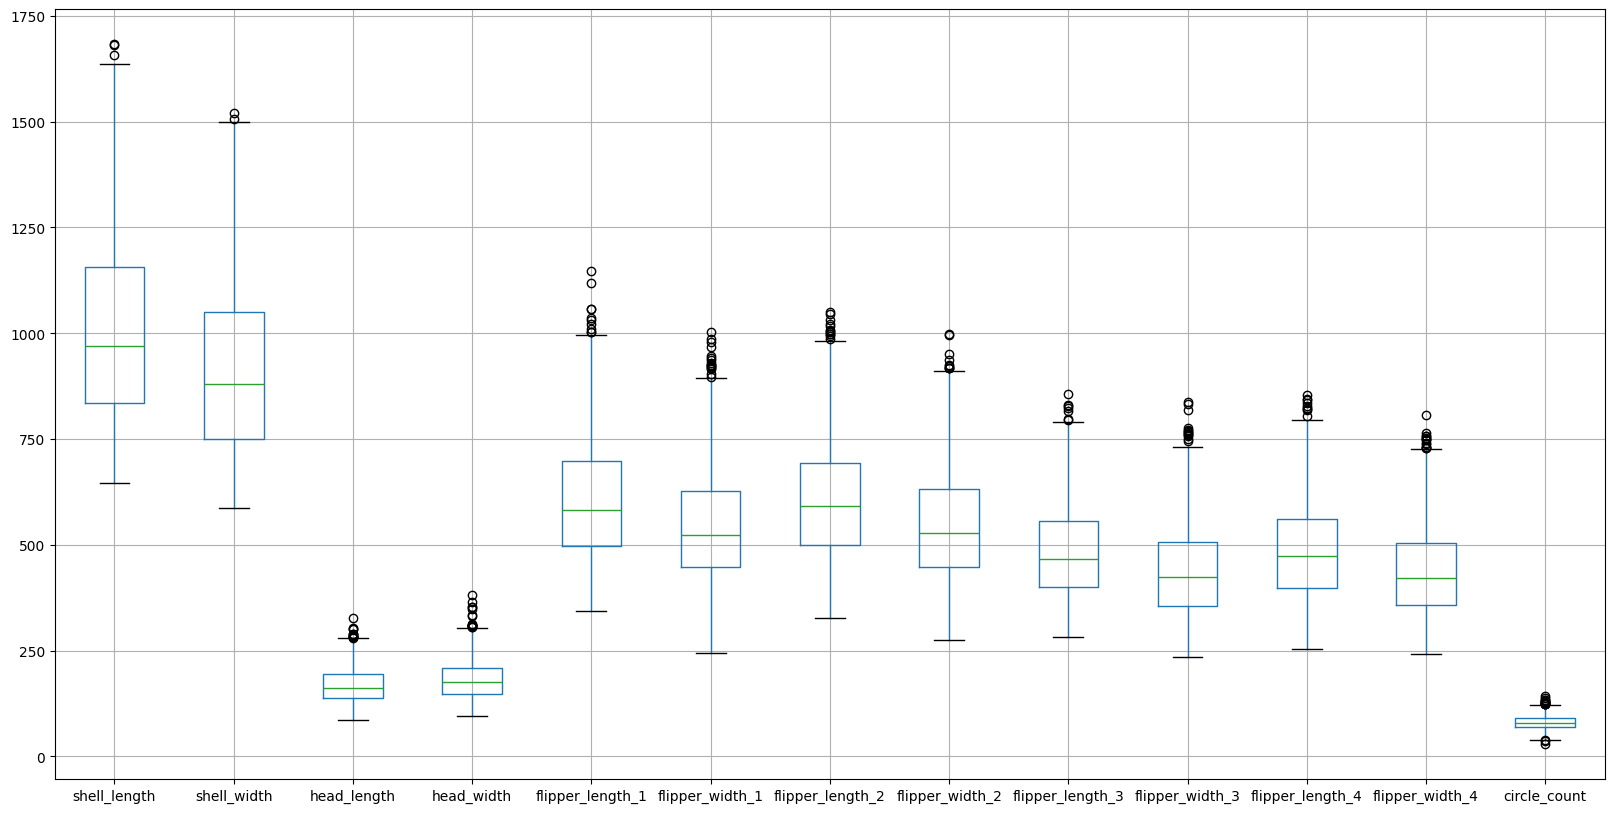

In [46]:
X_train.boxplot(figsize=(20, 10)) 

In [47]:
for col in feature_columns:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_val[col] = X_val[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

In [48]:
show_missing_stats(X_train)

'Пропусков в данных нет'

In [49]:
show_missing_stats(X_val)

'Пропусков в данных нет'

In [50]:
show_missing_stats(X_test)

'Пропусков в данных нет'

### Комментарий

Датасет `df_chelodia_mydas` содержит небольшое количество пропусков в признаках `shell_length`, `head_length`, `head_width`, `flipper_length_3`, `flipper_width_3`, `flipper_length_4`, `flipper_width_4`. Число этих пропусков в отдельности на кажлый признак составляеь немногим более **1%**, но объекты с пропусками в замерах панциря, головы и плавников не пеерсекаются, что ведет у увеличению общего числа строк с пропусками в каких-либо признаках.  
Принято решение заполнить пропуски мерой центральной тенденции: *медианой* или *средним значением*. На основании характера распределения признаков (скошенное вправо) была выбрана *медиана*.  
С целью предотвращения утечки данных медианы для каждого признака были рассчитаны на основе выборки X_train, а затем этими значениями заполнены пропуски во всех выборках X_train, X_val, X_test.  
После обработки пропуски в данных отсутствуют.
_______

### 3.3- 3.4 Функция масштабирования признаков

In [51]:
# Масштабирование
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min_val) / (max_val - min_val)
        X_val_scaled = (X_val - min_val) / (max_val - min_val)
        X_test_scaled = (X_test - min_val) / (max_val - min_val)
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled

### Комментарий

Создана функция для масштабирования признаков методом стандартизации и мин-макс нормализации.
__________ 

### 3.5 Подготовка двух дополнительных датасетов: стандартизированного и нормализованного

In [52]:
X_train_standard, X_val_standard, X_test_standard = scale_data(X_train, X_val, X_test, method='standard')
X_train_norm, X_val_norm, X_test_norm = scale_data(X_train, X_val, X_test, method='minmax')


In [53]:
X_train_standard.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
count,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03,1.489000e+03
mean,-4.504103e-08,-3.457169e-08,-7.722678e-08,7.358378e-08,3.962341e-08,-4.228596e-08,1.859816e-07,-1.954680e-07,-1.878572e-08,-6.051101e-08,-9.076100e-08,1.312802e-08,-2.863168e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.999999e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.674513e+00,-1.611724e+00,-1.985527e+00,-1.894797e+00,-1.865682e+00,-2.318649e+00,-2.047779e+00,-2.083697e+00,-1.860605e+00,-1.949932e+00,-2.105438e+00,-1.870983e+00,-3.222214e+00
25%,-8.036714e-01,-8.077783e-01,-7.739468e-01,-7.680058e-01,-7.720337e-01,-7.558541e-01,-7.991505e-01,-7.684878e-01,-7.698694e-01,-7.842490e-01,-7.859643e-01,-7.715547e-01,-6.870573e-01
50%,-1.904346e-01,-1.616623e-01,-1.681567e-01,-1.493752e-01,-1.793470e-01,-1.784667e-01,-1.312796e-01,-1.378027e-01,-1.649237e-01,-1.536337e-01,-1.262275e-01,-1.692593e-01,-6.872650e-02
75%,6.462119e-01,6.768087e-01,6.072547e-01,6.018191e-01,6.391251e-01,6.221773e-01,6.091859e-01,6.620905e-01,6.325048e-01,6.394128e-01,6.509966e-01,6.242409e-01,6.114374e-01
max,3.058125e+00,2.994935e+00,3.854290e+00,4.424073e+00,3.807177e+00,3.516813e+00,3.193556e+00,3.461717e+00,3.409756e+00,3.802044e+00,3.326094e+00,3.511434e+00,3.826758e+00


In [54]:
X_train_norm.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
count,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000
mean,0.353822,0.349868,0.339998,0.299863,0.328879,0.397338,0.390698,0.375751,0.353032,0.339002,0.387632,0.347610,0.457118
std,0.211299,0.217077,0.171238,0.158256,0.176278,0.171366,0.190791,0.180329,0.189740,0.173853,0.184110,0.185790,0.141865
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.184008,0.174518,0.207469,0.178322,0.192786,0.267810,0.238227,0.237171,0.206957,0.202658,0.242928,0.204263,0.359649
50%,0.313584,0.314775,0.311203,0.276224,0.297264,0.366755,0.365651,0.350902,0.321739,0.312292,0.364393,0.316163,0.447368
75%,0.490366,0.496788,0.443983,0.395105,0.441542,0.503958,0.506925,0.495146,0.473043,0.450166,0.507488,0.463588,0.543860
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [55]:
X_train.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
count,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000
mean,1012.267639,913.777039,168.939560,181.760910,607.418396,546.182007,609.083923,546.916748,484.993286,439.079254,486.967102,438.704498,81.111484
std,219.328003,202.749985,41.268417,45.261257,141.727493,129.895447,137.751175,130.017349,109.100693,104.659691,110.650192,104.599846,16.172572
min,645.000000,587.000000,87.000000,96.000000,343.000000,245.000000,327.000000,276.000000,282.000000,235.000000,254.000000,243.000000,29.000000
25%,836.000000,750.000000,137.000000,147.000000,498.000000,448.000000,499.000000,447.000000,401.000000,357.000000,400.000000,358.000000,70.000000
50%,970.500000,881.000000,162.000000,175.000000,582.000000,523.000000,591.000000,529.000000,467.000000,423.000000,473.000000,421.000000,80.000000
75%,1154.000000,1051.000000,194.000000,209.000000,698.000000,627.000000,693.000000,633.000000,554.000000,506.000000,559.000000,504.000000,91.000000
max,1683.000000,1521.000000,328.000000,382.000000,1147.000000,1003.000000,1049.000000,997.000000,857.000000,837.000000,855.000000,806.000000,143.000000


In [56]:
X_train_sets = dict(X_train=X_train, X_train_standard=X_train_standard, X_train_norm=X_train_norm)

### Комментарий

Подготовлено 3 группы датасетов для построения прогнозной линейной модели:  
1) Обучающая выборка. Датасет X_train c  исходными данными. X_train_standard - датасет со стандартизованными данными. X_train_norm- датасет с нормализованными данными.
2) Валидационная выборка. Датасеты X_val, X_val_standard, X_val_norm.
3) Тестовая выборка. Датасеты X_test, X_test_standard и X_test_norm.

__________ 

## Результаты предобработки данных


В рамках этапа предобработки данных был выполнен комплекс мероприятий, обеспечивший готовность датасета к построению прогнозной линейной модели для предсказания массы морских черепах вида *Chelonia mydas*.


Первоначально датасет `df_chelodia_mydas` был разделён на матрицу «объект‑признак» `X`, включающую атрибуты измерений длины и ширины панциря, головы, плавников и числа колец на панцире, и целевую переменную `y` с замерами веса черепах. Далее обе выборки были структурированы путём разделения на три части: обучающую (60 %), валидационную (20 %) и тестовую (20 %).

Следующий этап включал обработку пропусков в признаках `shell_length`, `head_length`, `head_width`, `flipper_length_3`, `flipper_width_3`, `flipper_length_4` и `flipper_width_4`. Несмотря на то что доля пропусков по каждому признаку составляла немногим более 1 %, общее число строк с пропусками в каких‑либо признаках оказалось выше из‑за отсутствия пересечений между объектами с пропусками в разных параметрах. С учётом скошенного вправо распределения признаков для заполнения пропусков была выбрана медиана. Медианы рассчитывались исключительно на основе обучающей выборки `X_train`, что исключило риск утечки данных. Затем этими значениями были заполнены пропуски во всех выборках — `X_train`, `X_val` и `X_test`. В результате после обработки пропуски в данных полностью отсутствуют.

Дополнительно была создана универсальная функция для масштабирования признаков, реализующая два метода: стандартизацию и мин‑макс нормализацию. На её основе подготовлены три группы датасетов для каждого типа выборки (обучающей, валидационной и тестовой): исходные данные, стандартизованные данные (`_standard`) и нормализованные данные (`_norm`). Это позволит в дальнейшем оценить влияние разных подходов к масштабированию на качество прогнозной модели.

Данные успешно прошли все этапы предобработки: разделение на выборки, заполнение пропусков без утечки информации и подготовку масштабированных версий датасетов. 
___________

## 4. Обучение моделей

### 4.1 Базовая модель: константный предикт

In [57]:
def calculate_metrics(y_true, y_pred, model_class='default', model_name='default'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'model_class': model_class,
            'model_name': model_name,
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'MAPE': round(mape * 100, 2),
            'R2': round(r2, 3)}

In [58]:
model_results = {}
y_pred_const = np.ones(len(y_train)) * np.mean(y_train)

model_results['baseline'] = calculate_metrics(y_pred_const, y_train, model_class='baseline', model_name='baseline')
model_results['baseline']

{'model_class': 'baseline',
 'model_name': 'baseline',
 'MAE': 28.37,
 'RMSE': 34.81,
 'MAPE': 29.75,
 'R2': 0.0}

### Комментарий

Параметры `baseline` базовой модели константного предикта на основе среднего значения по выборке y_train:  
- **MAE = 28.37**
- **RMSE = 34.81**
- **MAPE = 29.75%**
_________

### 4.2 Обучение линейных моделей: LinearRegression, Lasso, Ridge, SGDRegressor 

#### 4.2.1 Линейная регрессия с аналитическим решением

In [59]:
model = LinearRegression()

print('Обучение аналитической модели Линейной регрессии (LR) \n')
for s in X_train_sets:
    model.fit(X_train_sets[s], y_train)
    y_pred = model.predict(X_train_sets[s])
    print(f'Коэффициенты LR выборки {s}:', *model.coef_[0].round(4))
    print(f'Свободный коэф. LR выборки {s}:', *model.intercept_.round(4))
    model_class = 'LR'
    model_name = f'LR {s}'
    model_results[model_name] = calculate_metrics(y_pred, y_train, model_class=model_class, model_name=model_name)
    print(model_results[model_name], '\n')

Обучение аналитической модели Линейной регрессии (LR) 

Коэффициенты LR выборки X_train: 0.0444 0.0375 0.0387 0.0338 0.0246 0.0148 0.0181 0.0095 0.0193 0.0132 0.0128 0.0156 0.0361
Свободный коэф. LR выборки X_train: -66.9109
{'model_class': 'LR', 'model_name': 'LR X_train', 'MAE': 3.76, 'RMSE': 4.86, 'MAPE': 4.28, 'R2': 0.98} 

Коэффициенты LR выборки X_train_standard: 9.7318 7.5938 1.5951 1.5316 3.4815 1.9271 2.4985 1.2306 2.1067 1.3863 1.4168 1.6342 0.5833
Свободный коэф. LR выборки X_train_standard: 95.3533
{'model_class': 'LR', 'model_name': 'LR X_train_standard', 'MAE': 3.76, 'RMSE': 4.86, 'MAPE': 4.28, 'R2': 0.98} 

Коэффициенты LR выборки X_train_norm: 46.0568 34.9821 9.3151 9.6781 19.75 11.2456 13.0957 6.8243 11.103 7.9739 7.6955 8.7958 4.1115
Свободный коэф. LR выборки X_train_norm: 27.5618
{'model_class': 'LR', 'model_name': 'LR X_train_norm', 'MAE': 3.76, 'RMSE': 4.86, 'MAPE': 4.28, 'R2': 0.98} 



In [60]:
X_train.corr(method='pearson').style.background_gradient(cmap='coolwarm')

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
shell_length,1.000000,0.946047,0.856302,0.839566,0.909268,0.885497,0.905358,0.888440,0.897075,0.876215,0.903119,0.876054,0.506288
shell_width,0.946047,1.000000,0.853503,0.833147,0.902312,0.883612,0.906973,0.880702,0.894019,0.869226,0.897328,0.878839,0.496949
head_length,0.856302,0.853503,1.000000,0.762221,0.809778,0.783608,0.812648,0.784834,0.800345,0.778355,0.804301,0.798571,0.450298
head_width,0.839566,0.833147,0.762221,1.000000,0.796001,0.775502,0.801145,0.778562,0.791322,0.773353,0.807818,0.783861,0.444677
flipper_length_1,0.909268,0.902312,0.809778,0.796001,1.000000,0.845585,0.869274,0.838749,0.845678,0.830803,0.860807,0.830544,0.477058
flipper_width_1,0.885497,0.883612,0.783608,0.775502,0.845585,1.000000,0.834784,0.820586,0.827769,0.808884,0.837497,0.813479,0.480864
flipper_length_2,0.905358,0.906973,0.812648,0.801145,0.869274,0.834784,1.000000,0.841420,0.850228,0.833091,0.851560,0.840607,0.464725
flipper_width_2,0.888440,0.880702,0.784834,0.778562,0.838749,0.820586,0.841420,1.000000,0.826844,0.810937,0.834588,0.808044,0.476516
flipper_length_3,0.897075,0.894019,0.800345,0.791322,0.845678,0.827769,0.850228,0.826844,1.000000,0.835570,0.864923,0.837421,0.462279
flipper_width_3,0.876215,0.869226,0.778355,0.773353,0.830803,0.808884,0.833091,0.810937,0.835570,1.000000,0.841350,0.821520,0.450880


In [61]:
X_train.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
count,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000
mean,1012.267639,913.777039,168.939560,181.760910,607.418396,546.182007,609.083923,546.916748,484.993286,439.079254,486.967102,438.704498,81.111484
std,219.328003,202.749985,41.268417,45.261257,141.727493,129.895447,137.751175,130.017349,109.100693,104.659691,110.650192,104.599846,16.172572
min,645.000000,587.000000,87.000000,96.000000,343.000000,245.000000,327.000000,276.000000,282.000000,235.000000,254.000000,243.000000,29.000000
25%,836.000000,750.000000,137.000000,147.000000,498.000000,448.000000,499.000000,447.000000,401.000000,357.000000,400.000000,358.000000,70.000000
50%,970.500000,881.000000,162.000000,175.000000,582.000000,523.000000,591.000000,529.000000,467.000000,423.000000,473.000000,421.000000,80.000000
75%,1154.000000,1051.000000,194.000000,209.000000,698.000000,627.000000,693.000000,633.000000,554.000000,506.000000,559.000000,504.000000,91.000000
max,1683.000000,1521.000000,328.000000,382.000000,1147.000000,1003.000000,1049.000000,997.000000,857.000000,837.000000,855.000000,806.000000,143.000000


In [62]:
# Feature engineering

X_fe = pd.DataFrame()
X_fe['shell_l2'] = np.sqrt(X_train['shell_length']**2 + X_train['shell_width']**2)
X_fe['head_l2'] = np.sqrt(X_train['head_length']**2 + X_train['head_width']**2)
X_fe['flipper_l2_mean'] = 0.25*(np.sqrt(X_train['flipper_length_1']**2 + X_train['flipper_width_1']**2) + np.sqrt(X_train['flipper_length_2']**2 + X_train['flipper_width_2']**2) + np.sqrt(X_train['flipper_length_3']**2 + X_train['flipper_width_3']**2) + np.sqrt(X_train['flipper_length_4']**2 + X_train['flipper_width_4']**2))
X_train_sets['X_fe'] = X_fe

X_fe.head()

,shell_l2,head_l2,flipper_l2_mean
1446,1378.557251,250.990036,748.010681
1890,1376.401489,273.855804,779.727783
1960,1846.837891,362.492767,999.381409
970,1226.554565,222.847488,623.897095
983,1178.752319,221.269073,621.964539


In [63]:
model.fit(X_fe, y_train)

y_pred = model.predict(X_fe)
print(f'Коэффициенты LR выборки FE:', *model.coef_[0].round(4))
print(f'Свободный коэф. LR выборки FE:', *model.intercept_.round(4))
model_class = 'LR'
model_name = f'LR X_fe'
model_results[model_name] = calculate_metrics(y_pred, y_train, model_class=model_class, model_name=model_name)
print(model_results[model_name], '\n')

Коэффициенты LR выборки FE: 0.0601 0.0504 0.0897
Свободный коэф. LR выборки FE: -65.3311
{'model_class': 'LR', 'model_name': 'LR X_fe', 'MAE': 3.81, 'RMSE': 4.89, 'MAPE': 4.34, 'R2': 0.98} 



In [64]:
pd.DataFrame(model_results)

,baseline,LR X_train,LR X_train_standard,LR X_train_norm,LR X_fe
model_class,baseline,LR,LR,LR,LR
model_name,baseline,LR X_train,LR X_train_standard,LR X_train_norm,LR X_fe
MAE,28.37,3.76,3.76,3.76,3.81
RMSE,34.81,4.86,4.86,4.86,4.89
MAPE,29.75,4.28,4.28,4.28,4.34
R2,0.0,0.98,0.98,0.98,0.98


In [65]:
pd.DataFrame(model_results).T

,model_class,model_name,MAE,RMSE,MAPE,R2
baseline,baseline,baseline,28.37,34.81,29.75,0.0
LR X_train,LR,LR X_train,3.76,4.86,4.28,0.98
LR X_train_standard,LR,LR X_train_standard,3.76,4.86,4.28,0.98
LR X_train_norm,LR,LR X_train_norm,3.76,4.86,4.28,0.98
LR X_fe,LR,LR X_fe,3.81,4.89,4.34,0.98


#### Комментарий по обучению аналитической модели линейной регрессии

Всего было обучено 4 модели линейной регрессии с аналитическим решением:
1) **LR X_train** на основе обучающего датасета без масштабирования признаков X_train
2) **LR X_train_standard** на основе датасета со стандартизацией признаков X_train_standard
3) **LR X_train_norm** c использованием датасета нормализованных признаков (мин-макс) X_train_norm
4) Модель **LR FE** на основе доработанных признаков (feature engineering). Так как признаки имеют сильную корреляцию, были исключены те, которые наименее коррелированы с целевой переменной, а оставшиеся преобразованы в новые признаки. Новые признаки расчитаны как L2 норма замеров длины и ширины панциря (новый признак `shell_l2`), L2 норма длины и ширины головы `head_l2` и средняя по L2 нормам длины и ширины плавников `flipper_l2_mean`.

Коэффициенты признаков и свободный коэффициент первых трёх моделей различаются, но метрики подностью совпадают **'MAE': 3.76, 'RMSE': 4.86, 'MAPE': 4.22, 'R2': 0.98** для всех трёх.  
Метрики модели **LR FE** получились немного хуже предыдущих моделей **'MAE': 3.81, 'RMSE': 4.89, 'MAPE': 4.27, 'R2': 0.98**.

______

#### 4.2.2 Линейная регрессия с L1-регуляризацией (Lasso)

In [66]:
alpha_list = [0.1, 1, 10]

for alpha in alpha_list:
    print(f'Обучение Линейной регрессии с регуляризацией L1 (Lasso) alpha={alpha} \n')
    print('-----------------------------------------------------')
    model = Lasso(alpha=alpha)
    for s in X_train_sets:
        model.fit(X_train_sets[s], y_train)
        y_pred = model.predict(X_train_sets[s])
        print(f'Коэффициенты Lasso выборки {s}:', model.coef_.round(4))
        print(f'Свободный коэф. Lasso выборки {s}:', model.intercept_.round(4))
        model_class = 'R1 Lasso'
        model_name = f'R1 Lasso {s} alpha={alpha}'
        model_results[model_name] = calculate_metrics(y_pred, y_train, model_class=model_class, model_name=model_name)
        print(model_results[model_name], '\n')
    print('-----------------------------------------------------')

Обучение Линейной регрессии с регуляризацией L1 (Lasso) alpha=0.1 

-----------------------------------------------------
Коэффициенты Lasso выборки X_train: [0.0444 0.0375 0.0385 0.0338 0.0246 0.0149 0.0182 0.0095 0.0193 0.0132
 0.0128 0.0156 0.0355]
Свободный коэф. Lasso выборки X_train: [-66.8871]
{'model_class': 'R1 Lasso', 'model_name': 'R1 Lasso X_train alpha=0.1', 'MAE': 3.76, 'RMSE': 4.86, 'MAPE': 4.28, 'R2': 0.98} 

Коэффициенты Lasso выборки X_train_standard: [9.845  7.6603 1.5609 1.5009 3.46   1.898  2.4709 1.1982 2.0785 1.3553
 1.4016 1.6085 0.5197]
Свободный коэф. Lasso выборки X_train_standard: [95.3533]
{'model_class': 'R1 Lasso', 'model_name': 'R1 Lasso X_train_standard alpha=0.1', 'MAE': 3.75, 'RMSE': 4.87, 'MAPE': 4.25, 'R2': 0.98} 

Коэффициенты Lasso выборки X_train_norm: [5.37129e+01 4.16140e+01 6.44920e+00 6.13730e+00 1.70975e+01 8.26240e+00
 1.21540e+01 4.77190e+00 1.01275e+01 5.53180e+00 6.72390e+00 7.57570e+00
 7.90000e-03]
Свободный коэф. Lasso выборки X_train

#### Комментарий по обучению модели линейной регрессии с L1-регуляризацией (Lasso)

В обучении моделей линейной регрессии на основе **L1-регуляризации Lasso** были использованы все три обучающие выборки (X_train, X_train_standard, X_train_norm) и различные варианты коэффциента гиперпараметра для штрафа функции потерь `alpha`.
Для `alpha` был выбраны значения [0.1, 1, 10]. Лучшие метрики показали модели обученные ны выборках `X_train` и `X_train_standard` со значениями alpha **0.1** и **1**.  При значении **alpha = 0.1** показатели модели близки к показателям простой линейной регрессии, что объясняется минимальным значеним штрафа для функции.  
Лучшее значение достигнуто на выборке `X_train` при **alpha = 0.1** 'MAE': 3.75, 'RMSE': 4.87, 'MAPE': 4.19, 'R2': 0.98.  
Худшие показатели показывают модели с высоким значением aplha на нормализованной выборке `X_train_norm`. При значении alpha = 10 результат обучения на нормализованной выборке сравнялся с метриками `baseline` 'MAE': 28.37, 'RMSE': 34.81, 'MAPE': 32.21, 'R2': 0.0. Модель занулила все коэффициенты признаков и оставила только свбодный коэффициент. По сути это привело ее к предсказанию среднего значения (наша базовая модель).

______

#### 4.2.3 Линейная регрессия с L2-регуляризацией (Ridge)

In [67]:
alpha_list = [0.1, 1, 10]

for alpha in alpha_list:
    print(f'Обучение Линейной регрессии с регуляризацией L2 (Ridge) alpha={alpha} \n')
    print('-----------------------------------------------------')
    model = Ridge(alpha=alpha)
    for s in X_train_sets:
        model.fit(X_train_sets[s], y_train)
        y_pred = model.predict(X_train_sets[s])
        print(f'Коэффициенты Lasso выборки {s}:', model.coef_.round(4))
        print(f'Свободный коэф. Lasso выборки {s}:', model.intercept_.round(4))
        model_class = 'R2 Ridge'
        model_name = f'R2 Ridge {s} alpha={alpha}'
        model_results[model_name] = calculate_metrics(y_pred, y_train, model_class=model_class, model_name=model_name)
        print(model_results[model_name], '\n')
    print('-----------------------------------------------------')

Обучение Линейной регрессии с регуляризацией L2 (Ridge) alpha=0.1 

-----------------------------------------------------
Коэффициенты Lasso выборки X_train: [0.0444 0.0375 0.0387 0.0338 0.0246 0.0148 0.0181 0.0095 0.0193 0.0132
 0.0128 0.0156 0.0361]
Свободный коэф. Lasso выборки X_train: [-66.9109]
{'model_class': 'R2 Ridge', 'model_name': 'R2 Ridge X_train alpha=0.1', 'MAE': 3.76, 'RMSE': 4.86, 'MAPE': 4.28, 'R2': 0.98} 

Коэффициенты Lasso выборки X_train_standard: [9.7247 7.5902 1.5962 1.5322 3.4823 1.9284 2.4998 1.2322 2.1078 1.3873
 1.4182 1.635  0.5835]
Свободный коэф. Lasso выборки X_train_standard: [95.3533]
{'model_class': 'R2 Ridge', 'model_name': 'R2 Ridge X_train_standard alpha=0.1', 'MAE': 3.76, 'RMSE': 4.86, 'MAPE': 4.28, 'R2': 0.98} 

Коэффициенты Lasso выборки X_train_norm: [45.3874 34.7123  9.4306  9.7293 19.7791 11.3735 13.2294  7.0107 11.2185
  8.0839  7.8601  8.8902  4.1464]
Свободный коэф. Lasso выборки X_train_norm: [27.4651]
{'model_class': 'R2 Ridge', 'model_n

#### Комментарий по обучению модели линейной регрессии с L2-регуляризацией (Ridge)

Модели основе L2-регуляризации Ridge более стабильны в метриках при изменении параметров и обучающих выборок по сравнению с Lasso, но показывают ровно ту же тенденцию: с ростом значения alpha и на выборке `X_train_norm` результаты становятся хуже. Наилучшие результаты достигаются на выборках `X_train` и `X_train_standard` при минимальном alpha. Это подталкивает к предположению, что в нашем случае модель без регуляризации будет оптимальной.     
В обучении моделей линейной регрессии на основе **L2-регуляризации Ridge** были также использованы все обучающие выборки: X_train, X_train_standard, X_train_norm.
Для гиперпараметра `alpha` был выбраны значения [0.1, 1, 10]. Лучшие метрики показали модели обученные ны выборках `X_train` и `X_train_standard` со значениями alpha **0.1** и **1** 'MAE': 3.76, 'RMSE': 4.86, 'MAPE': 4.22, 'R2': 0.98.  
______

#### 4.2.4 Линейная регрессия на основе градиентного спуска (SGDRegressor)

#### loss='squared_error'

In [68]:
learning_rate = 'constant'
eta0 = 0.01
max_iter = 1000
tol = 1e-3
alpha = 0.01
loss='squared_error'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_norm, y_train)
y_pred = model.predict(X_train_norm)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))


Коэффициенты: [24.5012 23.4062 12.9591 11.6152 17.5065 14.3856 16.3708 13.1777 14.7904
 12.401  13.6425 13.0699  5.7495]
Свободный коэф.: [25.7058]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 3.91, 'RMSE': 5.22, 'MAPE': 4.19, 'R2': 0.977}


In [69]:
learning_rate = 'adaptive'
eta0 = 0.01
max_iter = 1000
tol = 1e-3
alpha = 0.01
loss='squared_error'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_norm, y_train) # X_train_norm
y_pred = model.predict(X_train_norm)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))


Коэффициенты: [24.6605 23.5434 12.9882 11.6739 17.5797 14.4048 16.418  13.2277 14.8884
 12.4619 13.7004 13.1633  5.6986]
Свободный коэф.: [25.5948]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 3.91, 'RMSE': 5.19, 'MAPE': 4.21, 'R2': 0.978}


In [70]:
learning_rate = 'invscaling'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.1
loss='squared_error'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_norm, y_train) # X_train_norm
y_pred = model.predict(X_train_norm) 
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [15.9775 16.164  11.2493 10.1957 12.6427 11.8394 13.4214 12.137  12.9797
 11.5232 12.635  12.3393  5.7865]
Свободный коэф.: [38.0086]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 6.88, 'RMSE': 9.15, 'MAPE': 7.23, 'R2': 0.931}


In [71]:
learning_rate = 'optimal'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.1
loss='squared_error'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_norm, y_train)
y_pred = model.predict(X_train_norm)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [16.1127 16.2338 11.2057 10.1813 12.7056 11.7538 13.4417 12.1083 13.0005
 11.5978 12.4411 12.3114  5.4845]
Свободный коэф.: [38.2547]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 6.92, 'RMSE': 9.16, 'MAPE': 7.3, 'R2': 0.931}


#### loss='epsilon_insensitive'

In [72]:
learning_rate = 'constant'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.01
loss='epsilon_insensitive'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_train_standard)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [6.5453 5.1811 2.1377 1.4964 3.6292 2.3616 2.842  2.0755 2.4303 2.0837
 2.1426 2.455  0.7832]
Свободный коэф.: [94.99]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 3.82, 'RMSE': 5.1, 'MAPE': 4.13, 'R2': 0.979}


In [73]:
# Лучшая модель на обучающей выборке
learning_rate = 'adaptive'
eta0 = 0.1
max_iter = 5000
tol = 1e-3
alpha = 0.001
loss='epsilon_insensitive'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_train_standard)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [11.1729  6.1165  1.5221  1.1155  3.1847  1.7115  2.1745  1.7     1.786
  1.7259  1.1882  1.7686  0.6782]
Свободный коэф.: [95.1271]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 3.68, 'RMSE': 4.98, 'MAPE': 4.0, 'R2': 0.98}


In [74]:
learning_rate = 'invscaling'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.01
loss='epsilon_insensitive'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_train_standard)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [5.3048 4.7093 2.1408 1.6053 3.5133 2.6246 2.9613 2.3489 2.7082 2.2982
 2.3996 2.6059 0.7755]
Свободный коэф.: [95.0093]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 3.9, 'RMSE': 5.25, 'MAPE': 4.17, 'R2': 0.977}


In [75]:
learning_rate = 'optimal'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.01
loss='epsilon_insensitive'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_train_standard)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [6.5894 5.1329 1.959  1.4576 3.4779 2.2338 2.7201 2.1403 2.4018 2.0058
 2.1146 2.3393 0.706 ]
Свободный коэф.: [94.9824]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 3.87, 'RMSE': 5.29, 'MAPE': 4.04, 'R2': 0.977}


#### loss='huber'

In [76]:
learning_rate = 'constant'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.01
loss='huber'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_train_standard)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [3.3474 3.1944 2.4018 2.2517 2.9084 2.5937 2.7851 2.5669 2.739  2.6001
 2.7431 2.6102 1.1112]
Свободный коэф.: [94.0992]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 4.5, 'RMSE': 6.53, 'MAPE': 4.41, 'R2': 0.965}


In [77]:
learning_rate = 'adaptive'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.01
loss='huber'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_train_standard)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [3.3513 3.1965 2.4011 2.2482 2.905  2.5977 2.7789 2.5676 2.7375 2.5972
 2.7301 2.6027 1.1189]
Свободный коэф.: [94.1511]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 4.51, 'RMSE': 6.53, 'MAPE': 4.41, 'R2': 0.965}


In [78]:
learning_rate = 'invscaling'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.01
loss='huber'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_train_standard)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [2.7626 2.711  2.19   2.0992 2.5148 2.3253 2.5292 2.3064 2.4153 2.2553
 2.496  2.3329 0.983 ]
Свободный коэф.: [89.4788]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 6.99, 'RMSE': 10.68, 'MAPE': 6.01, 'R2': 0.906}


In [79]:
learning_rate = 'optimal'
eta0 = 0.01
max_iter = 5000
tol = 1e-3
alpha = 0.01
loss='huber'

model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model.fit(X_train_standard, y_train)
y_pred = model.predict(X_train_standard)
print(f'Коэффициенты:', model.coef_.round(4))
print(f'Свободный коэф.:', model.intercept_.round(4))
print(calculate_metrics(y_train, y_pred, model_class='SGDRegressor', model_name='manual'))

Коэффициенты: [2.6911 2.6461 2.1481 2.0622 2.4535 2.2835 2.4817 2.2714 2.3676 2.2083
 2.4454 2.2919 0.988 ]
Свободный коэф.: [88.8616]
{'model_class': 'SGDRegressor', 'model_name': 'manual', 'MAE': 7.48, 'RMSE': 11.39, 'MAPE': 6.38, 'R2': 0.893}


In [80]:
learning_rate_list = ['constant', 'optimal', 'invscaling', 'adaptive']
eta0_list = [0.001, 0.01, 0.1, 1]
max_iter = 5000
tol = 1e-3
alpha_list = [0.0001, 0.001, 0.01, 0.1, 1, 10]
loss_list = ['squared_error', 'epsilon_insensitive', 'huber']

for s in X_train_sets:
    for loss in loss_list:
        for learning_rate in learning_rate_list:
            for eta0 in eta0_list:
                for alpha in alpha_list:
                    model = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)
                    model.fit(X_train_sets[s], y_train)
                    y_pred = model.predict(X_train_sets[s])
                    model_class = 'SGDRegressor'
                    model_name = f'SGDRegressor {s} {loss} {learning_rate} eta0={eta0}, alpha={alpha}'
                    model_results[model_name] = calculate_metrics(y_pred, y_train, model_class=model_class, model_name=model_name)

In [81]:
df_results = pd.DataFrame(model_results).T.reset_index(drop=True)
df_results.shape

(1181, 6)

In [82]:
df_results.sort_values(by='MAE').head(10)

,model_class,model_name,MAE,RMSE,MAPE,R2
599,SGDRegressor,"SGDRegressor X_train_standard huber adaptive eta0=1, alpha=0.0001",3.68,4.98,4.04,0.978
491,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive adaptive eta0=0.01, alpha=0.0001",3.68,4.98,4.04,0.978
504,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive adaptive eta0=1, alpha=0.001",3.68,4.98,4.03,0.978
503,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive adaptive eta0=1, alpha=0.0001",3.68,4.99,4.04,0.978
497,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.0001",3.68,5.0,4.03,0.978
498,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.001",3.68,4.98,4.03,0.978
473,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive invscaling eta0=0.1, alpha=0.0001",3.69,5.0,4.0,0.978
419,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive constant eta0=0.01, alpha=0.0001",3.69,5.01,3.99,0.978
456,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive optimal eta0=1, alpha=0.001",3.7,5.07,3.96,0.977
551,SGDRegressor,"SGDRegressor X_train_standard huber optimal eta0=1, alpha=0.0001",3.7,5.08,3.95,0.977


#### Комментарий по обучению модели линейной регрессии SGDRegressor

С целью определения оптимальной модели линейной регрессии со стохастическим градиентым спуском было выбрано несколько **loss функций: 'squared_error', 'epsilon_insensitive', 'huber'**.  
Выбраны следующие параметры **learning_rate: 'constant', 'optimal', 'invscaling', 'adaptive'**.  
Значения для коэффициента штрафа loss функции **alpha: [0.0001, 0.001, 0.01, 0.1, 1, 10]**.
Шаг градиента **eta0 [0.001, 0.01, 0.1, 1]**.  
Обучение проводилось на 4-х обучающих выборках: `X_train`, `X_train_standard`, `X_train_norm`, `X_fe` (обучающая выборка на основе новых расчитанных признаков).

Сначала была предпринята опытка в ручную найти оптимальную модель. Наилучшие результаты показала модель на выборке `X_train_standard` с парематрами:

learning_rate = 'adaptive'  
eta0 = 0.1  
max_iter = 5000  
tol = 1e-3  
alpha = 0.001  
loss='epsilon_insensitive'  

Полученные метрики: 'MAE': 3.68, 'RMSE': 4.98, 'MAPE': 4.0, 'R2': 0.98.  

Затем было принято решение перебрать в цикле все возможные параметры на всех обучающих выборках. Еще пять моделей дали аналогичные метрики. Принято решение использовать модель, посчитанную в ручную, как наилучшую в классе моделей `SGDRegressor`.


______

### 4.2.5 Результат обучения моделей линейной регрессии

In [83]:
# Преобразуем столбцы с метриками в числовой тип (float)
df_results['MAE'] = pd.to_numeric(df_results['MAE'], errors='coerce')
df_results['RMSE'] = pd.to_numeric(df_results['RMSE'], errors='coerce')
df_results['MAPE'] = pd.to_numeric(df_results['MAPE'], errors='coerce')
df_results['R2'] = pd.to_numeric(df_results['R2'], errors='coerce')

In [84]:
min_mae_per_class = df_results.groupby('model_class')['MAE'].transform('min')
best_results = df_results[df_results['MAE'] == min_mae_per_class]
min_r2_per_class = best_results.groupby('model_class')['R2'].transform('min')
best_results = best_results[best_results['R2'] == min_r2_per_class]
min_rmse_per_class = best_results.groupby('model_class')['RMSE'].transform('min')
best_results = best_results[best_results['RMSE'] == min_rmse_per_class]
min_mape_per_class = best_results.groupby('model_class')['MAPE'].transform('min')
best_results = best_results[best_results['MAPE'] == min_mape_per_class]
best_results

,model_class,model_name,MAE,RMSE,MAPE,R2
0,baseline,baseline,28.37,34.81,29.75,0.000
1,LR,LR X_train,3.76,4.86,4.28,0.980
2,LR,LR X_train_standard,3.76,4.86,4.28,0.980
3,LR,LR X_train_norm,3.76,4.86,4.28,0.980
6,R1 Lasso,R1 Lasso X_train_standard alpha=0.1,3.75,4.87,4.25,0.980
17,R2 Ridge,R2 Ridge X_train alpha=0.1,3.76,4.86,4.28,0.980
18,R2 Ridge,R2 Ridge X_train_standard alpha=0.1,3.76,4.86,4.28,0.980
19,R2 Ridge,R2 Ridge X_train_norm alpha=0.1,3.76,4.86,4.28,0.980
21,R2 Ridge,R2 Ridge X_train alpha=1,3.76,4.86,4.28,0.980
22,R2 Ridge,R2 Ridge X_train_standard alpha=1,3.76,4.86,4.28,0.980


### Итоги обучения моделей линейной регрессии на обучающих выборках

На обучающих выборках `X_train`, `X_train_standard`, `X_train_norm` и `X_fe` было  **1164** модели, большая часть которых приходится на класс `SGDRegressor` ввиду пеербора большого количества гиперпараметров.  
В финальный список лучших моделей вошли 3 модели класса аналитичекой линейной ргерессии `LR`. На трёх выборках `X_train`, `X_train_standard`, `X_train_norm` был показан одинаковый результат **MAE = 3.76, RMSE = 4.86, MAPE = 4.28, R2 = 0.98**.  
Модель с регуляризацией R1 `Lasso` с гмперпараметром **alpha = 0.1** имеет значения метрик **MAE = 3.79, RMSE = 4.86, MAPE = 4.28, R2 = 0.98**.  
Модель с R2 регуляризацией `Ridge` вошла в 6-ти вариантах в разных выборках `X_train`, `X_train_standard` и гиперпараметром **alpha 0.1 и 1** и с одной выборкой `X_train_norm` с **alpha = 10**. Общий результат для всех 6-ти моделей Ridge: **MAE = 3.76, RMSE = 4.86, MAPE = 4.28, R2 = 0.98**, что совпадает с резульатами простой аналитичекой линейной регрессии `LR`.  
Класс линейной регрессии со стохастическим градиентым спуском представлен двумя моделями на выборке `X_train_standard`, loss = 'epsilon_insensitive', learning_rate = 'adaptive', минимальным alpha = 0.001 и двумя вариантами eta0 = 0.1 и 1. Модели показали самые лучшие метрики `MAE` и `MAPE` на обучающих выборках: **MAE = 3.68, RMSE = 4.98, MAPE = 4.03, R2 = 0.978**.
________________

## 5. Сравнение моделей на валидационной выборке

### 5.1 Сравним построенные модели по метрикам на валидационной выборке

In [85]:
# Создадим словарь для сохранения результатов валидационной выборки
model_val_results = {}

# Создадим константный предикт для валидационной выборки
y_pred_const = np.ones(len(y_val)) * np.mean(y_train)
model_val_results['baseline'] = calculate_metrics(y_pred_const, y_val, model_class='baseline', model_name='baseline')

# Модель обычной линейно регрессии
model_lr = LinearRegression()

print('Проверка модели Линейной регрессии (LR) на валидационной выборке X_val \n')
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_val)
model_val_results['LR X_val'] = calculate_metrics(y_pred, y_val, model_class='LR', model_name='LR X_val')
print(model_val_results['LR X_val'], '\n')

Проверка модели Линейной регрессии (LR) на валидационной выборке X_val 

{'model_class': 'LR', 'model_name': 'LR X_val', 'MAE': 3.76, 'RMSE': 5.18, 'MAPE': 4.07, 'R2': 0.979} 



In [86]:
print('Проверка модели Линейной регрессии (LR) на валидационной выборке X_val_standard \n')
model_lr.fit(X_train_standard, y_train)
y_pred = model_lr.predict(X_val_standard)
model_val_results['LR X_val_standard'] = calculate_metrics(y_pred, y_val, model_class='LR', model_name='LR X_val_standard')
print(model_val_results['LR X_val_standard'], '\n')

Проверка модели Линейной регрессии (LR) на валидационной выборке X_val_standard 

{'model_class': 'LR', 'model_name': 'LR X_val_standard', 'MAE': 3.76, 'RMSE': 5.18, 'MAPE': 4.07, 'R2': 0.979} 



In [87]:
print('Проверка модели Линейной регрессии (LR) на валидационной выборке X_val_norm \n')
model_lr.fit(X_train_norm, y_train)
y_pred = model_lr.predict(X_val_norm)
model_val_results['LR X_val_norm'] = calculate_metrics(y_pred, y_val, model_class='LR', model_name='LR X_val_norm')
print(model_val_results['LR X_val_norm'], '\n')

Проверка модели Линейной регрессии (LR) на валидационной выборке X_val_norm 

{'model_class': 'LR', 'model_name': 'LR X_val_norm', 'MAE': 3.76, 'RMSE': 5.18, 'MAPE': 4.07, 'R2': 0.979} 



In [88]:
model_lasso = Lasso(alpha=0.1)

print('Проверка модели R1 Lasso на валидационной выборке X_val \n')
model_lasso.fit(X_train_standard, y_train)
y_pred = model_lasso.predict(X_val_standard)
model_val_results['R1 Lasso X_val_standard alpha=0.1'] = calculate_metrics(y_pred, y_val, model_class='R1 Lasso', model_name='R1 Lasso X_val_standard alpha=0.1')
print(model_val_results['R1 Lasso X_val_standard alpha=0.1'], '\n')

Проверка модели R1 Lasso на валидационной выборке X_val 

{'model_class': 'R1 Lasso', 'model_name': 'R1 Lasso X_val_standard alpha=0.1', 'MAE': 3.75, 'RMSE': 5.18, 'MAPE': 4.04, 'R2': 0.979} 



In [89]:
alpha_list = [0.1, 1]
X_train_sets = dict(X_val=X_train, X_val_standard=X_train_standard, X_val_norm=X_train_norm)
X_val_sets = dict(X_val=X_val, X_val_standard=X_val_standard, X_val_norm=X_val_norm)

for alpha in alpha_list:
    print(f'Проверка на валидационной выборке модели с регуляризацией L2 (Ridge) alpha={alpha} \n')
    print('-----------------------------------------------------')
    model = Ridge(alpha=alpha)
    for s in X_train_sets:
        model.fit(X_train_sets[s], y_train)
        y_pred = model.predict(X_val_sets[s])
        print(f'Коэффициенты Lasso выборки {s}:', model.coef_.round(4))
        print(f'Свободный коэф. Lasso выборки {s}:', model.intercept_.round(4))
        model_class = 'R2 Ridge'
        model_name = f'R2 Ridge {s} alpha={alpha}'
        model_val_results[model_name] = calculate_metrics(y_pred, y_val, model_class=model_class, model_name=model_name)
        print(model_val_results[model_name], '\n')
    print('-----------------------------------------------------')
    print()

Проверка на валидационной выборке модели с регуляризацией L2 (Ridge) alpha=0.1 

-----------------------------------------------------
Коэффициенты Lasso выборки X_val: [0.0444 0.0375 0.0387 0.0338 0.0246 0.0148 0.0181 0.0095 0.0193 0.0132
 0.0128 0.0156 0.0361]
Свободный коэф. Lasso выборки X_val: [-66.9109]
{'model_class': 'R2 Ridge', 'model_name': 'R2 Ridge X_val alpha=0.1', 'MAE': 3.76, 'RMSE': 5.18, 'MAPE': 4.07, 'R2': 0.979} 

Коэффициенты Lasso выборки X_val_standard: [9.7247 7.5902 1.5962 1.5322 3.4823 1.9284 2.4998 1.2322 2.1078 1.3873
 1.4182 1.635  0.5835]
Свободный коэф. Lasso выборки X_val_standard: [95.3533]
{'model_class': 'R2 Ridge', 'model_name': 'R2 Ridge X_val_standard alpha=0.1', 'MAE': 3.76, 'RMSE': 5.18, 'MAPE': 4.07, 'R2': 0.979} 

Коэффициенты Lasso выборки X_val_norm: [45.3874 34.7123  9.4306  9.7293 19.7791 11.3735 13.2294  7.0107 11.2185
  8.0839  7.8601  8.8902  4.1464]
Свободный коэф. Lasso выборки X_val_norm: [27.4651]
{'model_class': 'R2 Ridge', 'model_na

In [90]:
best_results[best_results['model_class'] == 'SGDRegressor']

,model_class,model_name,MAE,RMSE,MAPE,R2
498,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.001",3.68,4.98,4.03,0.978
504,SGDRegressor,"SGDRegressor X_train_standard epsilon_insensitive adaptive eta0=1, alpha=0.001",3.68,4.98,4.03,0.978


In [91]:
learning_rate = 'adaptive'
eta0 = 0.1
max_iter = 5000
tol = 1e-3
alpha = 0.001
loss='epsilon_insensitive'

model_sgd = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model_sgd.fit(X_train_standard, y_train)
y_pred = model_sgd.predict(X_val_standard)
print(f'Коэффициенты:', model_sgd.coef_.round(4))
print(f'Свободный коэф.:', model_sgd.intercept_.round(4))
model_class = 'SGDRegressor'
model_name = 'SGDRegressor X_val_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.001'
model_val_results[model_name] = calculate_metrics(y_pred, y_val, model_class=model_class, model_name=model_name)
print(model_val_results[model_name], '\n')

Коэффициенты: [11.1729  6.1165  1.5221  1.1155  3.1847  1.7115  2.1745  1.7     1.786
  1.7259  1.1882  1.7686  0.6782]
Свободный коэф.: [95.1271]
{'model_class': 'SGDRegressor', 'model_name': 'SGDRegressor X_val_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.001', 'MAE': 3.73, 'RMSE': 5.39, 'MAPE': 3.9, 'R2': 0.976} 



In [92]:
learning_rate = 'adaptive'
eta0 = 1
max_iter = 5000
tol = 1e-3
alpha = 0.001
loss='epsilon_insensitive'

model_sgd = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model_sgd.fit(X_train_standard, y_train)
y_pred = model_sgd.predict(X_val_standard)
print(f'Коэффициенты:', model_sgd.coef_.round(4))
print(f'Свободный коэф.:', model_sgd.intercept_.round(4))
model_class = 'SGDRegressor'
model_name = 'SGDRegressor X_val_standard epsilon_insensitive adaptive eta0=1, alpha=0.001'
model_val_results[model_name] = calculate_metrics(y_pred, y_val, model_class=model_class, model_name=model_name)
print(model_val_results[model_name], '\n')

Коэффициенты: [11.1569  6.0486  1.5395  1.1331  3.1938  1.706   2.1996  1.7374  1.8111
  1.6739  1.211   1.7583  0.67  ]
Свободный коэф.: [95.1282]
{'model_class': 'SGDRegressor', 'model_name': 'SGDRegressor X_val_standard epsilon_insensitive adaptive eta0=1, alpha=0.001', 'MAE': 3.73, 'RMSE': 5.39, 'MAPE': 3.9, 'R2': 0.976} 



In [93]:
df_val_results = pd.DataFrame(model_val_results).T.reset_index(drop=True)
df_val_results.shape

(13, 6)

In [94]:
df_val_results

,model_class,model_name,MAE,RMSE,MAPE,R2
0,baseline,baseline,29.7,36.3,31.15,0.0
1,LR,LR X_val,3.76,5.18,4.07,0.979
2,LR,LR X_val_standard,3.76,5.18,4.07,0.979
3,LR,LR X_val_norm,3.76,5.18,4.07,0.979
4,R1 Lasso,R1 Lasso X_val_standard alpha=0.1,3.75,5.18,4.04,0.979
5,R2 Ridge,R2 Ridge X_val alpha=0.1,3.76,5.18,4.07,0.979
6,R2 Ridge,R2 Ridge X_val_standard alpha=0.1,3.76,5.18,4.07,0.979
7,R2 Ridge,R2 Ridge X_val_norm alpha=0.1,3.76,5.17,4.07,0.979
8,R2 Ridge,R2 Ridge X_val alpha=1,3.76,5.18,4.07,0.979
9,R2 Ridge,R2 Ridge X_val_standard alpha=1,3.76,5.17,4.07,0.979


### Комментарий

Метрики, рассчитанные по выбранным моделям на валидационой выборке очень близки по свои значениям к метрикам на обучающей выборке. Результат по сравнению с `baseline` улучшен значительно с **MAE = 29.7** до **MAE = 3.73** на лучшей модели валидационной выборки `SGDRegressor`.
__________   

### 5.2 Выбор лучшей модели по метрике MAE на валидационной выборке

In [95]:
# Преобразуем столбцы с метриками в числовой тип (float)
df_val_results['MAE'] = pd.to_numeric(df_val_results['MAE'], errors='coerce')
df_val_results['RMSE'] = pd.to_numeric(df_val_results['RMSE'], errors='coerce')
df_val_results['MAPE'] = pd.to_numeric(df_val_results['MAPE'], errors='coerce')
df_val_results['R2'] = pd.to_numeric(df_val_results['R2'], errors='coerce')

min_mae = df_val_results['MAE'].min()
df_val_results = df_val_results[df_val_results['MAE'] == min_mae]
df_val_results


,model_class,model_name,MAE,RMSE,MAPE,R2
11,SGDRegressor,"SGDRegressor X_val_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.001",3.73,5.39,3.9,0.976
12,SGDRegressor,"SGDRegressor X_val_standard epsilon_insensitive adaptive eta0=1, alpha=0.001",3.73,5.39,3.9,0.976


### Комментарий по лучшей модели валидационной выборки

Две модели `SGDRegressor` показывают одинаковый и лучший результат на **валидационной выборке**: **MAE = 3.73, RMSE = 5.39, MAPE = 3.9, R2 = 0.976**.  
Это модель линейной регрессии с случайным стахостическим градиентым спуском, показавшая лучший результат на стандартизированой обучающей выборке `X_train_standard`. Функция потерь `loss` = `epsilon_insensitive`. Шаг градиентного спуска адаптивный `adaptive` и очень низкое значения коэффициента штрафа функции потерь `alpha` = 0.001.  

Выбираем модель с гиперпараметром начального шага обучения eta0 = 0.1 как потенциально более стабильную.
__________   

## 6. Проверка лучшей модели на тестовой выборке

In [96]:
learning_rate = 'adaptive'
eta0 = 0.1
max_iter = 5000
tol = 1e-3
alpha = 0.001
loss='epsilon_insensitive'

model_sgd = SGDRegressor(loss=loss, learning_rate=learning_rate, eta0=eta0, max_iter=max_iter, tol=tol, alpha=alpha, random_state=random_state)

model_sgd.fit(X_train_standard, y_train)
y_pred = model_sgd.predict(X_test_standard)
print(f'Коэффициенты:', *model_sgd.coef_.round(4))
print(f'Свободный коэф.:', *model_sgd.intercept_.round(4))
model_class = 'SGDRegressor'
model_name = 'SGDRegressor X_test_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.001'
print(calculate_metrics(y_pred, y_test, model_class=model_class, model_name=model_name))


Коэффициенты: 11.1729 6.1165 1.5221 1.1155 3.1847 1.7115 2.1745 1.7 1.786 1.7259 1.1882 1.7686 0.6782
Свободный коэф.: 95.1271
{'model_class': 'SGDRegressor', 'model_name': 'SGDRegressor X_test_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.001', 'MAE': 3.69, 'RMSE': 5.0, 'MAPE': 3.89, 'R2': 0.977}


### Комментарий

Лучшая модель класса `SGDRegressor` (SGDRegressor X_test_standard epsilon_insensitive adaptive eta0=0.1, alpha=0.001) показала отличный результат на тестовой выборке. Признаки переобучения или недообучения модели отсутствуют.
Метрика `MAE` соответствует требованиям заказчика, не превышает заданного порога в 5 кг, и составляет **3.69**, что почти соответствует показателю обучающей выборки (3.68) и превышает результат на валидации (3.73).  
Метрика `R2` также соответствует изначальным требованиям (0.97) и объясняет почти **0.98** вариации веса черепах. Относительная ошибка `MAPE` находится на уровне 3.89%, что является хорошим итоговым результатом работы модели. Корень средней стандартной квадратичной ошибки `RMSE` = 5.0.

**Вывод: полученная модель соответствует требованиям заказчика и рекомендуется к внедрению в промышленную эксплуатацию для системы компьютерного зрения `TurtleCV`.

## 7. Оценка важности признаков

In [97]:
print(f'Свободный коэф.:', *model_sgd.intercept_.round(4))

Свободный коэф.: 95.1271


In [98]:
pd.DataFrame(dict(features = X_train.columns, coefs = model_sgd.coef_.round(4))).T

,0,1,2,3,4,5,6,7,8,9,10,11,12
features,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count
coefs,11.1729,6.1165,1.5221,1.1155,3.1847,1.7115,2.1745,1.7,1.786,1.7259,1.1882,1.7686,0.6782


### Комментарий

По абсолютным значениям наиболее важными признаками модели являются длина и ширина панциря `shell_length` **11.17** и `shell_width` **6.12**. На втором месте по значимости идут размеры плавников (**от 1.7 до 3.18**). Третьими по абсолютным значениям идут размеры головы - **1.11 - 1.52**.  
Эта последовательность выглядит логично с точки зрения предсказания нашей целевой переменной: чем больше панцирь, плавники и голова, тем крупнее морская черепаха, тем больше она весит.
И наименее значимым является число колец на панцире `circle_count`. Коэффициент равен **0.67**. С одной стороны, число колец говорит о возрасте животного, и чем старше черепаха, тем она, вероятно, должна быть крупнее и больше весить. С другой стороны, вполне можно встретить в дикой природе более крупные молодые особи и более мелкие возрастные.  
Свободный коэффициент 26.78 показывает базовый уровень массы морской черепахи. 
________________  

## 8. Функция для прогнозирования веса черепахи

In [99]:
def turtle_weight_predict(measure_list):
    """
    Прогнозирует вес морской черепахи по её габаритам, используя коэффициенты модели.

    measure_list - список, содержащий измерения габаритов морской черепахи в строго заданной последовательности:

    1) shell_length,
    2) shell_width,
    3) head_length,
    4) head_width,
    5) flipper_length_1,
    6) flipper_width_1,
    7) flipper_length_2,
    8) flipper_width_2,
    9) flipper_length_3,
    10) flipper_width_3,
    11) flipper_length_4,
    12) flipper_width_4,
    13) circle_count

    Возвращает:
    - float: прогнозируемый вес черепахи
    """

    feature_means = [1012.267639, 913.777039, 168.939560, 181.760910, 607.418396, 546.182007, 609.083923, 546.916748, 484.993286, 439.079254, 486.967102, 438.704498, 81.111484]
    feature_stds = [219.328003, 202.749985, 41.268417, 45.261257, 141.727493, 129.895447, 137.751175, 130.017349, 109.100693, 104.659691, 110.650192, 104.599846, 16.172572]
    coefficients = [11.1729, 6.1165, 1.5221, 1.1155, 3.1847, 1.7115, 2.1745, 1.7, 1.786, 1.7259, 1.1882, 1.7686, 0.6782]
    intercept = 95.1271

    # Создаём массив с входными данными
    features = np.array([measure_list])

    # Стандартизируем признаки: (x - mean) / std
    features_scaled = (features - feature_means) / feature_stds

    # Вычисляем прогноз по формуле линейной регрессии: y = Xw + b
    predicted_weight = np.dot(features_scaled, coefficients) + intercept

    return predicted_weight


In [101]:
df_chelodia_mydas.iloc[0]

shell_length        742.000000
shell_width         652.000000
head_length         118.000000
head_width          147.000000
flipper_length_1    411.000000
flipper_width_1     386.000000
flipper_length_2    507.000000
flipper_width_2     389.000000
flipper_length_3    414.000000
flipper_width_3     368.000000
flipper_length_4    311.000000
flipper_width_4     325.000000
circle_count         66.000000
weight               56.352001
Name: 0, dtype: float32

In [100]:
params = [742.0, 652.0, 118.0, 147.0, 411.0, 386.0, 507.0, 389.0, 414.0, 368.0, 311.0, 325.0, 66.0]

turtle_weight_predict(params)

array([53.74593321])

### Комментарий

Написана функция прогнозирования веса морской черепахи. Функция содержит рассчитанные коэффициенты модели coef_, intercept_, средние значения и стандартные  отклонения по обучающей выборке. Функция принимает на вход габариты новой черепахи (13 признаков), производит стандартизацию этих признаков на основании среднего и стандартного отклонения и считает прогнозируемый вес как поэлементное произведение стандартизированных параметров модели и коэффициентов с прибавлением свободного члена.
____________

## Общие выводы и рекомендации по дальнейшей работе

### Какие модели изучены?

В ходе работы были изучены и протестированы следующие модели линейной регрессии:

1. **Базовая модель (константный предиктор)** — предсказание среднего значения целевой переменной.
2. **Линейная регрессия (LinearRegression, LR)** — без регуляризации, на разных версиях датасетов:
   * без масштабирования;
   * со стандартизацией;
   * с мин‑макс нормализацией;
   * с feature engineering.
3. **Lasso (L1‑регуляризация)** — с разными значениями гиперпараметра `alpha` на всех типах датасетов.
4. **Ridge (L2‑регуляризация)** — аналогично Lasso, с разными `alpha`.
5. **SGDRegressor** — линейная регрессия со стохастическим градиентным спуском, с перебором различных комбинаций гиперпараметров (функции потерь, скорости обучения, шага градиента и т. д.).

---

### Какие результаты получены?

**Результаты базовой модели:**
* MAE = 28.37;
* RMSE = 34.81;
* MAPE = 29.75 %.

**Лучшие результаты на тестовой выборке (модель SGDRegressor):**
* **MAE = 3.69 кг** (ниже требуемых 5 кг);
* **R² = 0.98** (выше требуемых 0.97);
* RMSE = 5.0;
* MAPE = 3.89 %.

Все ключевые метрики соответствуют требованиям заказчика для популяции зелёных морских черепах массой от 50 до 150 кг.

---

### Рекомендуется ли итоговая модель к внедрению?

**Да, модель рекомендуется к внедрению** в промышленную эксплуатацию для системы компьютерного зрения TurtleCV.

**Обоснование:**
* Модель удовлетворяет всем критериям успешности: MAE ≤ 5 кг, R² ≥ 0.97.
* Признаки переобучения или недообучения отсутствуют — метрики на обучающей, валидационной и тестовой выборках близки друг к другу.
* Модель показывает стабильно высокую точность предсказаний на новых данных.

---

### Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?

**Лучшая модель:** SGDRegressor с параметрами:
* функция потерь: `loss = 'epsilon_insensitive'`;
* скорость обучения: `learning_rate = 'adaptive'`;
* начальный шаг градиента: `eta0 = 0.1`;
* коэффициент штрафа: `alpha = 0.001`;
* данные: стандартизованные (`X_train_standard`).

**Метрики на тестовой выборке:**
* MAE = 3.69;
* RMSE = 5.0;
* MAPE = 3.89 %;
* R² = 0.98.

**Способ обработки признаков:**
* стандартизация (Z‑score) — выполнена после разделения данных на выборки, чтобы избежать утечки информации;
* заполнение пропусков медианой по обучающей выборке;
* удаление выбросов (аномальные значения длины/ширины панциря, нулевые веса);
* исключение нерелевантных признаков (идентификаторы, временные метки и т. д.).

---

### Какие признаки наиболее важны для модели?

По абсолютным значениям коэффициентов модели, признаки ранжируются следующим образом:

1. **Длина панциря (`shell_length`)** — 11.17.
2. **Ширина панциря (`shell_width`)** — 6.12.
3. **Размеры плавников (`flipper_length_n`, `flipper_width_n`)** — от 1.7 до 3.18.
4. **Размеры головы (`head_length`, `head_width`)** — от 1.11 до 1.52.
5. **Число колец на панцире (`circle_count`)** — 0.67 (наименее значимый признак).

Свободный коэффициент (базовый уровень массы) — 26.78.

Высокая важность размеров панциря согласуется с корреляционным анализом: коэффициенты Пирсона для `shell_length` и `shell_width` составляют $0{,}97–0{,}98$.

---

### Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?

**Да, перспективы есть.**

**Обоснование:**
* Архитектура модели и подход к предобработке данных универсальны и могут быть адаптированы для других видов морских черепах.
* Система TurtleCV предоставляет стандартизированные измерения габаритов, которые, вероятно, коррелируют с массой и у других видов.
* Для новых видов потребуется:
    * сбор и разметка данных (аналогичные признаки + масса);
    * проверка распределения признаков и наличия выбросов;
    * переобучение модели на новом датасете (возможно, с тонкой настройкой гиперпараметров).

**Ограничения:**
* У разных видов может быть разная анатомия (например, соотношение размеров панциря и плавников), что повлияет на важность признаков.
* Возможно, потребуется добавить видоспецифичные признаки (если они доступны и измеримы).

---

### Предложения по дальнейшему развитию проекта

1. **Расширение датасета:**
    * Сбор данных по другим видам морских черепах (*Caretta caretta*, *Dermochelys coriacea* и т. д.) для обучения мультивидовой модели.
    * Увеличение объёма данных по *Chelonia mydas* для повышения устойчивости модели к редким случаям.

2. **Улучшение качества данных:**
    * Автоматизация проверки на выбросы в реальном времени (на этапе сбора данных).
    * Внедрение контроля качества измерений TurtleCV (например, проверка реалистичности габаритов перед записью).

3. **Развитие модели:**
    * Тестирование нелинейных моделей (Random Forest, Gradient Boosting, нейронные сети) для возможного улучшения точности.
    * Анализ ошибок модели: выявление случаев с высокой MAE и изучение их особенностей.

4. **Интеграция и мониторинг:**
    * Развёртывание модели в виде API для интеграции с TurtleCV.
    * Настройка мониторинга метрик качества в продакшене (отслеживание дрейфа данных, деградации модели).
    * Реализация механизма обратной связи: сравнение предсказаний с реальными замерами массы (где возможно) для периодического переобучения.

5. **Дополнительные функции:**
    * Добавление оценки неопределённости предсказания (например, доверительные интервалы для массы).
    * Прогнозирование других параметров (возраст, пол) на основе тех же данных, если появится соответствующая разметка.

---

## Итог

Разработанная модель SGDRegressor успешно решает задачу бесконтактного предсказания массы зелёных морских черепах с высокой точностью. Она готова к внедрению и может служить основой для масштабирования на другие виды и задачи центра «Тортилла».


https://github.com/TemaQDX/project_turtle